# WCCI transfer digest — what actually moves survival

One page of evidence for the `cas_hl` **shared-candidate** models trained on
`bus14` and evaluated on the 50 held-out `bus36_wcci_nomaint` test chronics.
It compresses every downloaded run under
`outputs/full_test_eval/shared/wcci` into four factors:

| factor | levels |
|---|---|
| **adaptation route** | bus14 zero-shot · MAPPO fine-tune · BC on greedy labels · MAPPO scratch |
| **reduced action space** | mk64 · mk128 · mk256 · mk512 · mk1024 |
| **eval heuristic** | none · global rho · local rho (thresholds 0.85–1.00) |
| **architecture** | NL / NLS · mean / typed-mean pooling · features f0/f1 · do-nothing head h0/h1 |

## The three numbers that matter

The 50 test chronics split into two very different populations, so a single
mean hides almost everything:

* **26 easy chronics** — do-nothing already survives to the end. Nothing can be
  gained here; an agent can only *break* them.
* **24 difficult chronics** — do-nothing fails. All the achievable headroom lives here.

So the notebook reports:

1. `overall_%` — mean survival over all 50 chronics. Comparable to the number in
   every result JSON, but dominated by the 26 free episodes.
2. **`hard_%` — mean survival over the 24 difficult chronics.** The headline metric.
3. **`capture_hard_%` — how much of the reachable headroom was captured**, measured
   against the one-step simulator-greedy oracle *restricted to the same action space*:

   $$\text{capture} = 100\times\frac{\text{agent}-\text{do nothing}}{\text{greedy}@mk-\text{do nothing}}$$

   0 % = no better than doing nothing; 100 % = as good as exhaustively simulating
   every candidate action in that same reduced action space.

   A useful property: when a system keeps all 26 easy chronics intact (as every
   top system here does, and as the greedy oracle does at most caps), `capture`
   computed on all 50 chronics and on the 24 difficult ones are *identical* — the
   free episodes cancel out of numerator and denominator. Capture is the one
   metric in this notebook that the easy chronics cannot inflate.

Supporting columns: `hard_rescues` (difficult chronics carried to the end, out of 24)
and `easy_kept` (easy chronics not broken, out of 26).

> **Caveat carried over from the earlier notebooks.** These same 50 chronics were
> inspected repeatedly while choosing action caps and rho thresholds, and every
> arm is a single seed. Treat all rankings as exploratory model selection, not as
> an unbiased test estimate.

In [50]:
from pathlib import Path
import json
import re
import textwrap
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")


def find_task_dir(start=Path.cwd()):
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        direct = candidate if candidate.name == "Topology_Task" else candidate / "Topology_Task"
        if (direct / "main.py").is_file():
            return direct
    raise FileNotFoundError("Could not locate Topology_Task")


def load_json(path):
    with Path(path).open(encoding="utf-8") as handle:
        return json.load(handle)


def local_path(path_string):
    """Map a cluster-side artifact path onto this checkout."""
    path = Path(path_string)
    if path.is_file():
        return path.resolve()
    if path.parts and path.parts[0] == "outputs":
        return TASK_DIR / path
    if "Topology_Task" in path.parts:
        index = path.parts.index("Topology_Task")
        return TASK_DIR.joinpath(*path.parts[index + 1:])
    return TASK_DIR / path


TASK_DIR = find_task_dir()
WCCI_RESULT_ROOT = TASK_DIR / "outputs" / "full_test_eval" / "shared" / "wcci"
BUS14_RESULT_ROOT = TASK_DIR / "outputs" / "full_test_eval" / "shared" / "bus14"
DO_NOTHING_PATH = (
    TASK_DIR / "outputs" / "do_nothing_eval" / "wcci_test_nomaint_50"
    / "do_nothing_summary.json"
)
GREEDY_ROOT = TASK_DIR / "outputs" / "greedy_wcci_nomaint_50"
EXPORT_DIR = TASK_DIR / "outputs" / "analysis" / "shared_wcci_transfer_digest"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_ENV = "bus36_wcci_nomaint"
N_EPISODES = 50
MK_ORDER = [64, 128, 256, 512, 1024]
ADAPTATION_ORDER = [
    "bus14 zero-shot",      # no target-grid gradient at all
    "MAPPO fine-tune",      # PPO on WCCI reward, warm-started from the bus14 actor
    "BC on greedy labels",  # supervised distillation of the simulator oracle
    "MAPPO scratch",        # PPO on WCCI from random init
]
HEURISTIC_ORDER = ["none", "global rho", "local rho"]
ADAPTATION_COLORS = {
    "bus14 zero-shot": "#4C78A8",
    "MAPPO fine-tune": "#F58518",
    "BC on greedy labels": "#B279A2",
    "MAPPO scratch": "#54A24B",
}
HEURISTIC_COLORS = {"none": "#9EC5E8", "global rho": "#B279A2", "local rho": "#E45756"}


def save_figure(fig, stem):
    path = EXPORT_DIR / f"{stem}.png"
    fig.savefig(path, dpi=170, bbox_inches="tight")
    return path


print("Task dir       :", TASK_DIR)
print("WCCI results   :", WCCI_RESULT_ROOT)
print("Digest exports :", EXPORT_DIR)

Task dir       : /Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task
WCCI results   : /Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task/outputs/full_test_eval/shared/wcci
Digest exports : /Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task/outputs/analysis/shared_wcci_transfer_digest


## 1. Reference frame: do-nothing floor and greedy ceiling

Everything below is read against two anchors evaluated on **exactly the same 50
chronics**:

* **do-nothing** — the floor. It already survives 26/50 chronics completely.
* **one-step simulator greedy** — the ceiling *for a given reduced action space*.
  At each step where `rho > 0.9` it simulates every candidate action and keeps the
  best. It cannot be beaten by a policy restricted to the same candidates except
  through better long-horizon planning, so it is the natural denominator for
  "how much of this action space did the policy actually exploit".

In [51]:
do_nothing_payload = load_json(DO_NOTHING_PATH)
baseline = pd.DataFrame(do_nothing_payload["episodes"])[[
    "chronic_fingerprint", "chronic_name", "survival", "steps", "max_steps",
    "full_survival",
]].rename(columns={
    "survival": "dn_survival",
    "steps": "dn_steps",
    "full_survival": "dn_full_survival",
})
assert len(baseline) == N_EPISODES and baseline["chronic_fingerprint"].is_unique
baseline["is_hard"] = ~baseline["dn_full_survival"]

HARD_FINGERPRINTS = set(baseline.loc[baseline["is_hard"], "chronic_fingerprint"])
N_HARD = len(HARD_FINGERPRINTS)
N_EASY = N_EPISODES - N_HARD
DN_OVERALL = 100 * baseline["dn_survival"].mean()
DN_HARD = 100 * baseline.loc[baseline["is_hard"], "dn_survival"].mean()

# --- greedy ceiling, one row per reduced action space -----------------------
def align_greedy_to_baseline(frame, summary_path):
    """Every greedy run substitutes one do-nothing-perfect chronic for another.

    The substitution was audited in the earlier full-test notebook and is benign:
    both the dropped and the added chronic have do-nothing survival 1.0 and greedy
    survival 1.0, so neither the overall mean nor the difficult cohort moves. Any
    other mismatch is refused.
    """
    greedy_ids = set(frame["greedy_chronic_fingerprint"].astype(str))
    baseline_ids = set(baseline["chronic_fingerprint"].astype(str))
    if greedy_ids == baseline_ids:
        return frame, "50 exact fingerprints"

    baseline_only = baseline_ids - greedy_ids
    greedy_only = greedy_ids - baseline_ids
    if not (len(baseline_only) == len(greedy_only) == 1):
        raise ValueError(f"{summary_path}: chronic sets differ by more than one episode")

    dropped = baseline.loc[baseline["chronic_fingerprint"] == next(iter(baseline_only))].iloc[0]
    added = frame.loc[frame["greedy_chronic_fingerprint"] == next(iter(greedy_only))].iloc[0]
    benign = (
        bool(dropped["dn_full_survival"])
        and bool(added["do_nothing_full_survival"])
        and bool(added["greedy_full_survival"])
        and np.isclose(added["do_nothing_survival"], 1.0)
        and np.isclose(added["greedy_survival"], 1.0)
    )
    if not benign:
        raise ValueError(
            f"{summary_path}: unaudited chronic substitution "
            f"{added['greedy_chronic_name']} -> {dropped['chronic_name']}"
        )
    frame = frame.copy()
    swap = frame["greedy_chronic_fingerprint"] == added["greedy_chronic_fingerprint"]
    frame.loc[swap, "greedy_chronic_fingerprint"] = dropped["chronic_fingerprint"]
    frame.loc[swap, "greedy_chronic_name"] = dropped["chronic_name"]
    return frame, (
        f"49 exact + 1 audited full-survival substitution "
        f"({added['greedy_chronic_name']} -> {dropped['chronic_name']})"
    )


greedy_rows, greedy_episode_frames, alignment_notes = [], [], {}
for summary_path in sorted(GREEDY_ROOT.glob("*/greedy_vs_do_nothing_summary.json")):
    payload = load_json(summary_path)
    if payload.get("env_id") != TARGET_ENV:
        continue
    cap_match = re.search(r"_mk(\d+)\.json$", str(payload.get("reduced_action_space", "")))
    if cap_match is None:
        continue
    frame = pd.DataFrame(payload["episodes"])
    if len(frame) != N_EPISODES:
        raise ValueError(f"{summary_path} does not hold {N_EPISODES} episodes")
    mk = int(cap_match.group(1))
    frame, alignment_notes[mk] = align_greedy_to_baseline(frame, summary_path)
    if not HARD_FINGERPRINTS <= set(frame["greedy_chronic_fingerprint"]):
        raise ValueError(f"{summary_path} is missing difficult chronics")
    frame = frame.assign(
        mk=mk,
        is_hard=frame["greedy_chronic_fingerprint"].isin(HARD_FINGERPRINTS),
    )
    greedy_episode_frames.append(frame)
    hard = frame.loc[frame["is_hard"]]
    easy = frame.loc[~frame["is_hard"]]
    greedy_rows.append({
        "mk": mk,
        "greedy_overall_pct": 100 * frame["greedy_survival"].mean(),
        "greedy_hard_pct": 100 * hard["greedy_survival"].mean(),
        "greedy_hard_rescues": int(hard["greedy_full_survival"].sum()),
        "greedy_easy_kept": int(easy["greedy_full_survival"].sum()),
    })

greedy_ceiling = pd.DataFrame(greedy_rows).sort_values("mk").reset_index(drop=True)
greedy_episodes = pd.concat(greedy_episode_frames, ignore_index=True)
GREEDY_OVERALL = greedy_ceiling.set_index("mk")["greedy_overall_pct"].to_dict()
GREEDY_HARD = greedy_ceiling.set_index("mk")["greedy_hard_pct"].to_dict()

display(Markdown(
    f"**Chronic cohorts** — {N_HARD} difficult (do-nothing fails) · "
    f"{N_EASY} easy (do-nothing survives to the end).\n\n"
    f"**Do-nothing floor** — overall `{DN_OVERALL:.2f}%` · difficult `{DN_HARD:.2f}%`."
))
display(greedy_ceiling.assign(
    headroom_overall_pp=lambda d: d["greedy_overall_pct"] - DN_OVERALL,
    headroom_hard_pp=lambda d: d["greedy_hard_pct"] - DN_HARD,
    chronic_alignment=lambda d: d["mk"].map(alignment_notes),
))

**Chronic cohorts** — 24 difficult (do-nothing fails) · 26 easy (do-nothing survives to the end).

**Do-nothing floor** — overall `56.00%` · difficult `8.34%`.

,mk,greedy_overall_pct,greedy_hard_pct,greedy_hard_rescues,greedy_easy_kept,headroom_overall_pp,headroom_hard_pp,chronic_alignment
0,32,67.89,33.11,4,26,11.89,24.77,49 exact + 1 audited full-survival substitutio...
1,64,81.85,67.88,9,23,25.85,59.54,49 exact + 1 audited full-survival substitutio...
2,128,84.73,68.19,12,26,28.73,59.85,49 exact + 1 audited full-survival substitutio...
3,256,97.56,94.92,20,26,41.56,86.58,49 exact + 1 audited full-survival substitutio...
4,512,88.27,77.12,16,25,32.27,68.78,49 exact + 1 audited full-survival substitutio...
5,1024,95.28,90.16,19,26,39.27,81.82,49 exact + 1 audited full-survival substitutio...


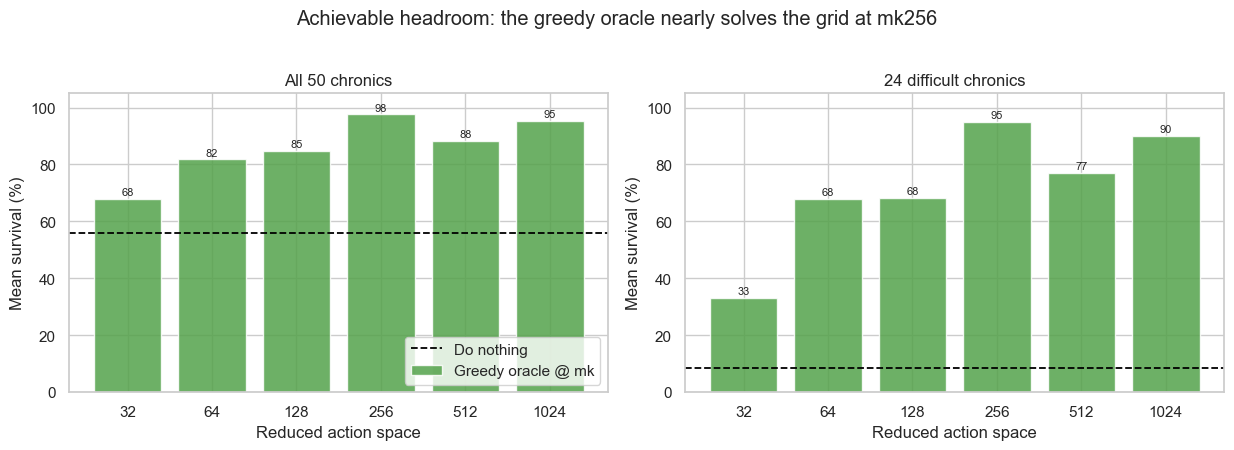

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4), sharex=True)
for ax, column, floor, title in (
    (axes[0], "greedy_overall_pct", DN_OVERALL, f"All {N_EPISODES} chronics"),
    (axes[1], "greedy_hard_pct", DN_HARD, f"{N_HARD} difficult chronics"),
):
    ax.bar(
        greedy_ceiling["mk"].astype(str), greedy_ceiling[column],
        color="#54A24B", alpha=0.85, label="Greedy oracle @ mk",
    )
    ax.axhline(floor, color="black", linestyle="--", linewidth=1.3, label="Do nothing")
    for x, y in zip(greedy_ceiling["mk"].astype(str), greedy_ceiling[column]):
        ax.text(x, y + 1.2, f"{y:.0f}", ha="center", fontsize=8)
    ax.set(xlabel="Reduced action space", ylabel="Mean survival (%)", title=title, ylim=(0, 105))
axes[0].legend(loc="lower right")
fig.suptitle("Achievable headroom: the greedy oracle nearly solves the grid at mk256", y=1.02)
fig.tight_layout()
save_figure(fig, "01_reference_frame")
plt.show()

## 2. Inventory: every downloaded run, factorised

Classification is driven by result metadata and the *checkpoint* path rather than
the download folder name, so freshly downloaded groups are picked up automatically.
Two things to know about the naming:

* `sc64c_*` checkpoints are **trained from scratch on WCCI**, even though they were
  downloaded next to the fine-tuned ones. They are labelled `WCCI scratch`.
* `ft64c_*` (5 M-step conservative fine-tune, mk64) and `trcas_*_finetune` /
  `ft_*` (early mk256 fine-tunes) are both `WCCI fine-tuned`, but at very different
  budgets — the `checkpoint_step` column keeps them distinguishable.

In [53]:
VARIANT_RE = re.compile(r"_(?P<pool>tmean|typed_mean|mean)_f(?P<features>[01])_a0h(?P<head>[01])")
SHORT_VARIANT_RE = re.compile(r"_(?P<pool>tm|m)f(?P<features>[01])h(?P<head>[01])(?:_|$)")
MK_RE = re.compile(r"_mk(\d+)")
HEURISTIC_LABELS = {
    "none": "none",
    "rho_threshold": "global rho",
    "local_rho_threshold": "local rho",
}


def parse_variant(*sources):
    for text in sources:
        match = VARIANT_RE.search(text)
        if match:
            pool = "tmean" if match.group("pool") in {"tmean", "typed_mean"} else "mean"
            return pool, int(match.group("features")), int(match.group("head"))
    for text in sources:
        match = SHORT_VARIANT_RE.search(text)
        if match:
            pool = "tmean" if match.group("pool") == "tm" else "mean"
            return pool, int(match.group("features")), int(match.group("head"))
    return "unknown", -1, -1


def classify_result(result_path):
    payload = load_json(result_path)
    checkpoint = str(payload.get("checkpoint", ""))
    checkpoint_stem = Path(checkpoint).stem
    stem = result_path.stem

    pool, features, head = parse_variant(checkpoint_stem, stem)
    family = "NLS" if "_NLS_" in f"{checkpoint_stem}_{stem}" else (
        "NL" if "_NL_" in f"{checkpoint_stem}_{stem}" else "other"
    )
    haystack = f"{checkpoint.lower()}/{result_path.parent.name.lower()}/{stem.lower()}"
    if "dangerous_graph_bc" in haystack or checkpoint_stem.startswith("bcg"):
        adaptation = "BC on greedy labels"
        # bcg_direct_bus14_* adapts the bus14 actor straight from the labels;
        # the other recipe distils on top of an existing MAPPO fine-tune.
        detail = "direct from bus14" if "direct_bus14" in checkpoint_stem else "on top of MAPPO fine-tune"
    elif "sc64c" in checkpoint_stem:
        adaptation = "MAPPO scratch"
        detail = "random init"
    elif "finetune" in checkpoint.lower() or checkpoint_stem.startswith("ft64c"):
        adaptation = "MAPPO fine-tune"
        detail = "warm start from bus14"
    else:
        adaptation = "bus14 zero-shot"
        detail = "no target-grid gradient"

    heuristic_raw = str(payload.get("eval_action_heuristic", "none") or "none")
    heuristic = HEURISTIC_LABELS.get(heuristic_raw, heuristic_raw)
    rho = float(payload.get("eval_action_rho_threshold", np.nan))
    if heuristic == "none":
        rho = np.nan

    mk_match = (
        MK_RE.search(str(payload.get("target_reduced_action_space", "") or ""))
        or MK_RE.search(result_path.parent.name)
        or MK_RE.search(stem)
    )
    artifact = (payload.get("action_artifacts") or {}).get("episode_summary_csv")
    artifact_path = local_path(artifact) if artifact else None

    return {
        "key": f"{result_path.parent.name}/{stem}",
        "group": result_path.parent.name,
        "run": stem,
        "adaptation": adaptation,
        "adaptation_detail": detail,
        "family": family,
        "pool": pool,
        "features": features,
        "head": head,
        "variant": f"{family}_{pool}_f{features}_a0h{head}",
        "mk": int(mk_match.group(1)) if mk_match else np.nan,
        "heuristic": heuristic,
        "rho": rho,
        "checkpoint": checkpoint,
        "checkpoint_stem": checkpoint_stem,
        "checkpoint_step": payload.get("checkpoint_global_step"),
        "reported_overall_pct": payload.get("survival_percent"),
        "target_env": payload.get("target_env_id"),
        "eval_episodes": payload.get("eval_episodes"),
        "episode_csv": str(artifact_path) if artifact_path else None,
        "has_episodes": bool(artifact_path and artifact_path.is_file()),
    }


inventory = pd.DataFrame(
    [classify_result(p) for p in sorted(WCCI_RESULT_ROOT.rglob("*.json"))]
)
comparable = (
    (inventory["target_env"] == TARGET_ENV) & (inventory["eval_episodes"] == N_EPISODES)
)
skipped = inventory.loc[~comparable]
inventory = inventory.loc[comparable].reset_index(drop=True)

for column, order in (("adaptation", ADAPTATION_ORDER), ("heuristic", HEURISTIC_ORDER)):
    inventory[column] = pd.Categorical(inventory[column], categories=order, ordered=True)

display(Markdown(
    f"**{len(inventory)} comparable WCCI evaluations** "
    f"({int(inventory['has_episodes'].sum())} with per-episode artifacts, "
    f"{int((~inventory['has_episodes']).sum())} overall-only)."
    + (f"  \n{len(skipped)} result files skipped as not comparable." if len(skipped) else "")
))
display(
    inventory.pivot_table(
        index=["adaptation", "heuristic"], columns="mk",
        values="key", aggfunc="size", fill_value=0, observed=True,
    )
)

**139 comparable WCCI evaluations** (126 with per-episode artifacts, 13 overall-only).

mk                              64    128   256   512   1024
adaptation          heuristic                               
bus14 zero-shot     none          16    16    16    16    16
                    local rho     17    11    10     0     0
MAPPO fine-tune     none           5     0     0     0     0
                    global rho     0     0     2     0     0
                    local rho      5     0     6     0     0
BC on greedy labels none           1     0     0     0     0
                    local rho      1     0     0     0     0
MAPPO scratch       none           1     0     0     0     0

### Coverage gap

Per-episode CSVs are what make the difficult/easy split possible. The runs listed
below were downloaded as summary JSON only, so they can be ranked on `overall_%`
but **not** on `hard_%`. Notably this includes the numerically top-ranked run
overall, **and the entire behaviour-cloning arm**, so the difficult-cohort leaderboard
further down is *conditional* on the runs that do have artifacts. Re-syncing
`outputs/full_test_eval_actions/shared/ft64c_wcci36_mk64*` and
`.../shared/dangerous_graph_bc/*` would close the gap — the BC arm is the highest
priority of the two, since §7b can currently only compare routes on `overall_pct`.

Separately, the two BC result JSONs point at the *same* artifact directory (the gated
run reuses the ungated run's path), so even once those files arrive one of the two
would be mis-attributed. The loader in §3 detects and rejects that automatically.

In [54]:
coverage_gap = inventory.loc[~inventory["has_episodes"], [
    "group", "run", "adaptation", "mk", "heuristic", "rho",
    "checkpoint_step", "reported_overall_pct",
]].sort_values("reported_overall_pct", ascending=False)
if len(coverage_gap):
    display(coverage_gap)
else:
    display(Markdown("_All comparable runs have per-episode artifacts._"))

,group,run,adaptation,mk,heuristic,rho,checkpoint_step,reported_overall_pct
88,ft64c_wcci36_mk64_localrho,ft64c_NLS_mean_f0_a0h0_s0_lr095,MAPPO fine-tune,64,local rho,0.95,4976640,63.65
82,ft64c_wcci36_mk64,best_test_sc64c_NLS_tmean_f0_a0h0_s0,MAPPO scratch,64,none,NaN,165888,63.16
81,dangerous_graph_bc,bcg_direct_bus14_cons1496_e12_lr30_bal040_w3_a...,BC on greedy labels,64,local rho,0.95,14929920,62.62
89,ft64c_wcci36_mk64_localrho,ft64c_NLS_mean_f0_a0h1_s0_lr095,MAPPO fine-tune,64,local rho,0.95,4976640,62.01
91,ft64c_wcci36_mk64_localrho,ft64c_NLS_mean_f1_a0h1_s0_lr095,MAPPO fine-tune,64,local rho,0.95,4976640,61.91
85,ft64c_wcci36_mk64,ft64c_NLS_mean_f1_a0h0_s0,MAPPO fine-tune,64,none,NaN,4976640,61.03
90,ft64c_wcci36_mk64_localrho,ft64c_NLS_mean_f1_a0h0_s0_lr095,MAPPO fine-tune,64,local rho,0.95,4976640,60.92
87,ft64c_wcci36_mk64,ft64c_NLS_tmean_f0_a0h0_s0,MAPPO fine-tune,64,none,NaN,4976640,60.38
92,ft64c_wcci36_mk64_localrho,ft64c_NLS_tmean_f0_a0h0_s0_lr095,MAPPO fine-tune,64,local rho,0.95,4976640,60.37
86,ft64c_wcci36_mk64,ft64c_NLS_mean_f1_a0h1_s0,MAPPO fine-tune,64,none,NaN,4976640,59.49


## 3. Metric construction

One row per evaluation. Every episode is joined to the do-nothing baseline on the
chronic fingerprint, so all deltas are strictly paired on identical chronics.

In [55]:
# Some result JSONs point at an artifact directory that belongs to a *different*
# evaluation of the same checkpoint (the gated BC run reuses the ungated run's
# path). Loading those blindly would silently attribute the wrong episodes, so
# every artifact is verified against the survival number stored in its own JSON
# and dropped if it disagrees.
episode_frames, rejected_artifacts = [], []
for row in inventory.loc[inventory["has_episodes"]].itertuples():
    frame = pd.read_csv(row.episode_csv).merge(
        baseline, on="chronic_fingerprint", validate="one_to_one",
        suffixes=("", "_baseline"),
    )
    if len(frame) != N_EPISODES:
        raise ValueError(f"{row.key}: expected {N_EPISODES} episodes, got {len(frame)}")
    recomputed = 100 * frame["survival"].mean()
    if not np.isclose(recomputed, row.reported_overall_pct, rtol=0, atol=1e-6):
        rejected_artifacts.append({
            "key": row.key,
            "reported_overall_pct": row.reported_overall_pct,
            "artifact_overall_pct": recomputed,
            "episode_csv": row.episode_csv,
        })
        continue
    frame["key"] = row.key
    episode_frames.append(frame)

rejected_artifacts = pd.DataFrame(rejected_artifacts)
if len(rejected_artifacts):
    shared_paths = (
        inventory.loc[inventory["has_episodes"]]
        .groupby("episode_csv")["key"].agg(list)
    )
    shared_paths = shared_paths[shared_paths.map(len) > 1]
    display(Markdown(
        f"⚠️ **{len(rejected_artifacts)} artifact(s) rejected** because the episodes on "
        "disk do not reproduce the survival number in the run's own JSON — the result "
        "points at another evaluation's artifact directory. These runs are kept in the "
        "`overall_pct` tables and excluded from all difficult-cohort metrics."
    ))
    display(rejected_artifacts)
    if len(shared_paths):
        display(Markdown("Artifact directories claimed by more than one run:"))
        display(shared_paths.rename("runs").to_frame())
inventory["has_episodes"] = inventory["key"].isin(
    {frame["key"].iloc[0] for frame in episode_frames}
)

episodes = pd.concat(episode_frames, ignore_index=True)
episodes["is_hard"] = episodes["chronic_fingerprint"].isin(HARD_FINGERPRINTS)
episodes["full_survival"] = np.isclose(episodes["survival"], 1.0)
episodes["delta_pp"] = 100 * (episodes["survival"] - episodes["dn_survival"])


def summarise(group):
    hard = group.loc[group["is_hard"]]
    easy = group.loc[~group["is_hard"]]
    rescued = hard["full_survival"]
    return pd.Series({
        "overall_pct": 100 * group["survival"].mean(),
        "hard_pct": 100 * hard["survival"].mean(),
        "hard_median_pct": 100 * hard["survival"].median(),
        "hard_rescues": int(rescued.sum()),
        "hard_pct_excl_rescues": (
            100 * hard.loc[~rescued, "survival"].mean() if (~rescued).any() else np.nan
        ),
        "hard_wins": int((hard["delta_pp"] > 1e-9).sum()),
        "hard_losses": int((hard["delta_pp"] < -1e-9).sum()),
        "easy_pct": 100 * easy["survival"].mean(),
        "easy_kept": int(easy["full_survival"].sum()),
    })


runs = (
    episodes.groupby("key", sort=False)
    .apply(summarise, include_groups=False)
    .reset_index()
)
runs = inventory.merge(runs, on="key", how="left")

# Every surviving artifact reproduces its own reported survival (verified above).
checked = runs.dropna(subset=["overall_pct"])
assert np.allclose(checked["overall_pct"], checked["reported_overall_pct"])
runs["overall_pct"] = runs["overall_pct"].fillna(runs["reported_overall_pct"])

# --- headroom capture against the greedy oracle at the same action space ----
runs["greedy_overall_pct"] = runs["mk"].map(GREEDY_OVERALL)
runs["greedy_hard_pct"] = runs["mk"].map(GREEDY_HARD)
runs["capture_overall_pct"] = 100 * (
    (runs["overall_pct"] - DN_OVERALL) / (runs["greedy_overall_pct"] - DN_OVERALL)
)
runs["capture_hard_pct"] = 100 * (
    (runs["hard_pct"] - DN_HARD) / (runs["greedy_hard_pct"] - DN_HARD)
)
runs["delta_overall_pp"] = runs["overall_pct"] - DN_OVERALL
runs["delta_hard_pp"] = runs["hard_pct"] - DN_HARD

DIGEST_COLUMNS = [
    "adaptation", "mk", "heuristic", "rho", "variant", "checkpoint_step",
    "overall_pct", "hard_pct", "hard_rescues", "easy_kept",
    "capture_hard_pct", "capture_overall_pct",
]
print(f"{len(runs)} runs scored · {int(runs['hard_pct'].notna().sum())} with difficult-cohort metrics")

139 runs scored · 126 with difficult-cohort metrics


## 4. Leaderboard

**Ranked by `hard_pct`** — survival on the 24 difficult chronics — because that is
where every point of real headroom sits. `overall_pct` is shown alongside to make
the distortion visible: two runs that differ by 20 pp on the difficult chronics
differ by only ~10 pp overall, since 26 of 50 episodes are free.

In [56]:
leaderboard = (
    runs.dropna(subset=["hard_pct"])
    .sort_values("hard_pct", ascending=False)
    .reset_index(drop=True)
)
leaderboard.insert(0, "rank", np.arange(1, len(leaderboard) + 1))

reference_rows = pd.DataFrame([
    {"rank": 0, "adaptation": "— do nothing —", "mk": np.nan, "heuristic": "",
     "rho": np.nan, "variant": "", "checkpoint_step": np.nan,
     "overall_pct": DN_OVERALL, "hard_pct": DN_HARD, "hard_rescues": 0,
     "easy_kept": N_EASY, "capture_hard_pct": 0.0, "capture_overall_pct": 0.0},
] + [
    {"rank": 0, "adaptation": "— greedy oracle —", "mk": row.mk, "heuristic": "",
     "rho": np.nan, "variant": "", "checkpoint_step": np.nan,
     "overall_pct": row.greedy_overall_pct, "hard_pct": row.greedy_hard_pct,
     "hard_rescues": row.greedy_hard_rescues, "easy_kept": row.greedy_easy_kept,
     "capture_hard_pct": 100.0, "capture_overall_pct": 100.0}
    for row in greedy_ceiling.itertuples()
])

display(Markdown("#### Top 20 by difficult-chronic survival"))
display(leaderboard.head(20)[["rank"] + DIGEST_COLUMNS])
display(Markdown("#### Anchors"))
display(reference_rows[["adaptation"] + DIGEST_COLUMNS[1:]])
display(Markdown("#### Bottom 5 — how badly naive transfer can fail"))
display(leaderboard.tail(5)[["rank"] + DIGEST_COLUMNS])

#### Top 20 by difficult-chronic survival

,rank,adaptation,mk,heuristic,rho,variant,checkpoint_step,overall_pct,hard_pct,hard_rescues,easy_kept,capture_hard_pct,capture_overall_pct
0,1,MAPPO fine-tune,256,local rho,0.95,NLS_mean_f0_a0h0,1410048,63.59,24.15,4.00,26.00,18.26,18.26
1,2,bus14 zero-shot,128,local rho,1.00,NL_tmean_f0_a0h1,14598144,63.36,23.67,4.00,26.00,25.61,25.61
2,3,bus14 zero-shot,256,local rho,0.95,NL_tmean_f0_a0h1,14598144,63.36,23.66,4.00,26.00,17.70,17.70
3,4,bus14 zero-shot,128,local rho,0.95,NL_tmean_f0_a0h1,14598144,63.36,23.66,4.00,26.00,25.60,25.60
4,5,bus14 zero-shot,128,local rho,0.90,NL_tmean_f0_a0h1,14598144,63.36,23.66,4.00,26.00,25.60,25.60
5,6,bus14 zero-shot,128,local rho,0.85,NL_tmean_f0_a0h1,14598144,63.36,23.66,4.00,26.00,25.60,25.60
6,7,MAPPO fine-tune,256,local rho,0.90,NLS_mean_f0_a0h0,1410048,63.05,23.01,4.00,26.00,16.95,16.95
7,8,bus14 zero-shot,64,local rho,0.95,NL_tmean_f0_a0h1,14598144,62.71,22.30,4.00,26.00,23.45,25.93
8,9,MAPPO fine-tune,256,local rho,0.95,NLS_mean_f1_a0h0,165888,62.51,21.91,4.00,26.00,15.67,15.67
9,10,MAPPO fine-tune,256,local rho,1.00,NLS_mean_f1_a0h0,165888,62.43,21.72,4.00,26.00,15.46,15.46


#### Anchors

,adaptation,mk,heuristic,rho,variant,checkpoint_step,overall_pct,hard_pct,hard_rescues,easy_kept,capture_hard_pct,capture_overall_pct
0,— do nothing —,NaN,,NaN,,NaN,56.00,8.34,0,26,0.00,0.00
1,— greedy oracle —,32.00,,NaN,,NaN,67.89,33.11,4,26,100.00,100.00
2,— greedy oracle —,64.00,,NaN,,NaN,81.85,67.88,9,23,100.00,100.00
3,— greedy oracle —,128.00,,NaN,,NaN,84.73,68.19,12,26,100.00,100.00
4,— greedy oracle —,256.00,,NaN,,NaN,97.56,94.92,20,26,100.00,100.00
5,— greedy oracle —,512.00,,NaN,,NaN,88.27,77.12,16,25,100.00,100.00
6,— greedy oracle —,"1,024.00",,NaN,,NaN,95.28,90.16,19,26,100.00,100.00


#### Bottom 5 — how badly naive transfer can fail

,rank,adaptation,mk,heuristic,rho,variant,checkpoint_step,overall_pct,hard_pct,hard_rescues,easy_kept,capture_hard_pct,capture_overall_pct
121,122,bus14 zero-shot,1024,none,NaN,NL_mean_f0_a0h0,12109824,0.05,0.05,0.00,0.00,-10.13,-142.47
122,123,bus14 zero-shot,256,none,NaN,NL_mean_f0_a0h1,14929920,0.05,0.05,0.00,0.00,-9.58,-134.63
123,124,bus14 zero-shot,256,none,NaN,NL_mean_f0_a0h0,12109824,0.05,0.05,0.00,0.00,-9.58,-134.63
124,125,bus14 zero-shot,128,none,NaN,NL_mean_f0_a0h1,14929920,0.05,0.05,0.00,0.00,-13.85,-194.76
125,126,bus14 zero-shot,512,none,NaN,NL_mean_f0_a0h1,14929920,0.05,0.05,0.00,0.00,-12.05,-173.41


In [57]:
overall_only = (
    runs.loc[~runs["has_episodes"]]
    .sort_values("overall_pct", ascending=False)
)
if len(overall_only):
    best_scored = leaderboard.sort_values("overall_pct", ascending=False).iloc[0]
    display(Markdown(
        "#### Runs rankable on `overall_pct` only\n\n"
        f"Best fully-scored run reaches `{best_scored['overall_pct']:.2f}%` overall; "
        f"the best artifact-less run reaches `{overall_only['overall_pct'].max():.2f}%`. "
        "Their difficult-cohort standing is unknown."
    ))
    display(overall_only[[
        "adaptation", "mk", "heuristic", "rho", "variant", "checkpoint_step",
        "overall_pct", "capture_overall_pct",
    ]])

#### Runs rankable on `overall_pct` only

Best fully-scored run reaches `63.59%` overall; the best artifact-less run reaches `63.65%`. Their difficult-cohort standing is unknown.

,adaptation,mk,heuristic,rho,variant,checkpoint_step,overall_pct,capture_overall_pct
88,MAPPO fine-tune,64,local rho,0.95,NLS_mean_f0_a0h0,4976640,63.65,29.58
82,MAPPO scratch,64,none,NaN,NLS_tmean_f0_a0h0,165888,63.16,27.69
81,BC on greedy labels,64,local rho,0.95,NLS_mean_f1_a0h0,14929920,62.62,25.62
89,MAPPO fine-tune,64,local rho,0.95,NLS_mean_f0_a0h1,4976640,62.01,23.25
91,MAPPO fine-tune,64,local rho,0.95,NLS_mean_f1_a0h1,4976640,61.91,22.85
85,MAPPO fine-tune,64,none,NaN,NLS_mean_f1_a0h0,4976640,61.03,19.46
90,MAPPO fine-tune,64,local rho,0.95,NLS_mean_f1_a0h0,4976640,60.92,19.01
87,MAPPO fine-tune,64,none,NaN,NLS_tmean_f0_a0h0,4976640,60.38,16.92
92,MAPPO fine-tune,64,local rho,0.95,NLS_tmean_f0_a0h0,4976640,60.37,16.89
86,MAPPO fine-tune,64,none,NaN,NLS_mean_f1_a0h1,4976640,59.49,13.48


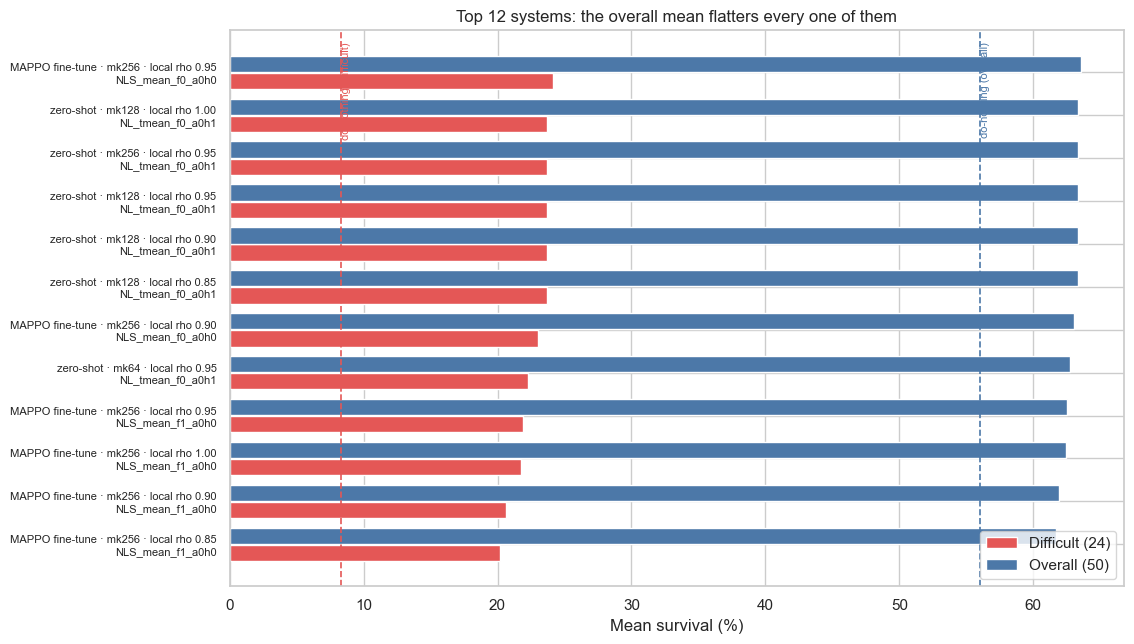

In [58]:
top = leaderboard.head(12).iloc[::-1]
labels = [
    f"{r.adaptation.replace('bus14 ', '')} · mk{int(r.mk)} · "
    f"{r.heuristic if r.heuristic == 'none' else f'{r.heuristic} {r.rho:.2f}'}\n{r.variant}"
    for r in top.itertuples()
]
fig, ax = plt.subplots(figsize=(11.5, 6.6))
positions = np.arange(len(top))
ax.barh(positions - 0.2, top["hard_pct"], height=0.38, color="#E45756", label=f"Difficult ({N_HARD})")
ax.barh(positions + 0.2, top["overall_pct"], height=0.38, color="#4C78A8", label=f"Overall ({N_EPISODES})")
ax.axvline(DN_HARD, color="#E45756", linestyle="--", linewidth=1.2)
ax.axvline(DN_OVERALL, color="#4C78A8", linestyle="--", linewidth=1.2)
ax.text(DN_HARD, len(top) - 0.3, " do-nothing (difficult)", color="#E45756", fontsize=8, rotation=90, va="top")
ax.text(DN_OVERALL, len(top) - 0.3, " do-nothing (overall)", color="#4C78A8", fontsize=8, rotation=90, va="top")
ax.set_yticks(positions, labels, fontsize=8)
ax.set(xlabel="Mean survival (%)", title="Top 12 systems: the overall mean flatters every one of them")
ax.legend(loc="lower right")
fig.tight_layout()
save_figure(fig, "02_leaderboard")
plt.show()

## 5. Factor 1 — reduced action space size

The zero-shot ungated arm is a complete factorial grid (2 families × 8 architecture
variants × 5 caps = 80 runs), so it isolates the action-cap effect cleanly.

Read the two panels together. The greedy line shows that **larger candidate sets
strictly contain more capability** — the oracle climbs from 68 % to 95 % on the
difficult cohort. The model lines show the opposite: averaged over the eight
architecture variants, difficult-cohort survival falls monotonically from mk64 to
mk1024, and even the *best* variant at each cap is flat from mk64 to mk256 before
collapsing at mk1024.

The gap between the two is the candidate-ranking problem. The extra actions are
there and the oracle finds them; a bus14-trained scorer cannot order unfamiliar
WCCI candidates, so every additional candidate is one more way to be wrong. This
is not a capacity limit — it is a scoring-generalisation limit.

,family,mk,runs,hard_mean,hard_best,hard_rescues_best,overall_mean,overall_best,easy_kept_mean,capture_hard_best
0,NL,64,8,5.35,12.53,1.00,22.96,58.00,9.50,7.04
1,NL,128,8,4.76,12.35,1.00,19.91,57.70,7.62,6.71
2,NL,256,8,3.45,10.01,1.00,14.22,54.99,4.88,1.93
3,NL,512,8,1.61,6.36,0.00,8.23,43.97,2.25,-2.89
4,NL,1024,8,0.54,1.09,0.00,5.54,39.75,2.00,-8.86
5,NLS,64,8,6.34,17.35,1.00,27.70,57.77,11.50,15.13
6,NLS,128,8,5.18,17.60,3.00,19.78,58.98,7.75,15.48
7,NLS,256,8,4.59,17.43,3.00,19.68,59.75,7.88,10.50
8,NLS,512,8,2.49,14.87,1.00,18.12,56.49,7.25,9.49
9,NLS,1024,8,0.35,1.20,0.00,0.93,5.47,0.00,-8.73


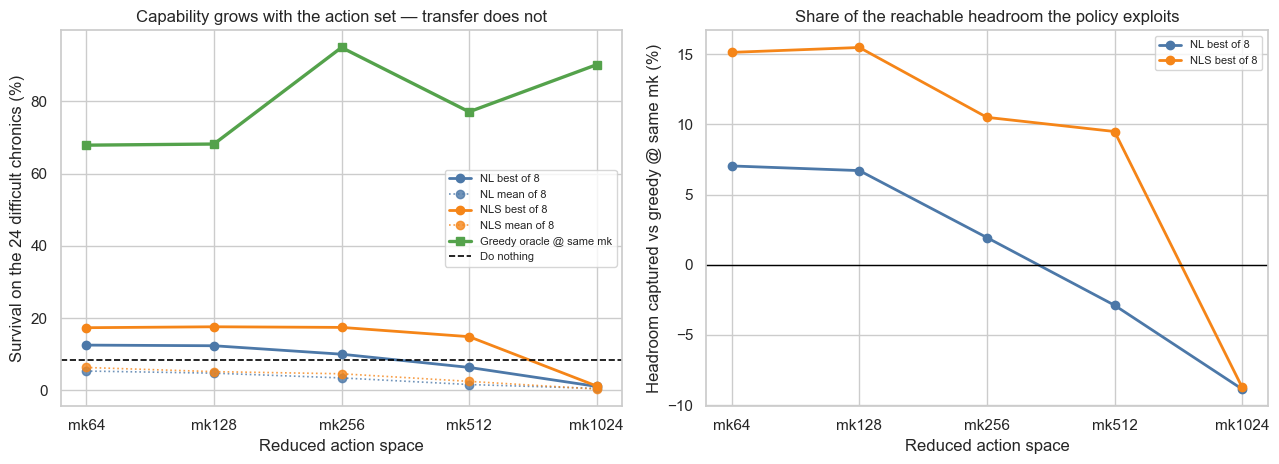

In [59]:
zero_ungated = runs.loc[
    (runs["adaptation"] == "bus14 zero-shot")
    & (runs["heuristic"] == "none")
    & runs["mk"].isin(MK_ORDER)
    & runs["hard_pct"].notna()
].copy()

cap_summary = (
    zero_ungated.groupby(["family", "mk"], as_index=False, observed=True)
    .agg(
        runs=("key", "size"),
        hard_mean=("hard_pct", "mean"),
        hard_best=("hard_pct", "max"),
        hard_rescues_best=("hard_rescues", "max"),
        overall_mean=("overall_pct", "mean"),
        overall_best=("overall_pct", "max"),
        easy_kept_mean=("easy_kept", "mean"),
        capture_hard_best=("capture_hard_pct", "max"),
    )
    .sort_values(["family", "mk"])
)
display(cap_summary)

FAMILY_COLORS = {"NL": "#4C78A8", "NLS": "#F58518"}
greedy_on_grid = greedy_ceiling.loc[greedy_ceiling["mk"].isin(MK_ORDER)].sort_values("mk")

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
for family, group in cap_summary.groupby("family"):
    group = group.sort_values("mk")
    colour = FAMILY_COLORS.get(family, "#777777")
    axes[0].plot(group["mk"], group["hard_best"], marker="o", linewidth=2,
                 color=colour, label=f"{family} best of 8")
    axes[0].plot(group["mk"], group["hard_mean"], marker="o", linewidth=1.2,
                 color=colour, linestyle=":", alpha=0.8, label=f"{family} mean of 8")
    axes[1].plot(group["mk"], group["capture_hard_best"], marker="o", linewidth=2,
                 color=colour, label=f"{family} best of 8")
axes[0].plot(greedy_on_grid["mk"], greedy_on_grid["greedy_hard_pct"], marker="s",
             color="#54A24B", linewidth=2.4, label="Greedy oracle @ same mk")
axes[0].axhline(DN_HARD, color="black", linestyle="--", linewidth=1.2, label="Do nothing")
axes[0].set(ylabel=f"Survival on the {N_HARD} difficult chronics (%)",
            title="Capability grows with the action set — transfer does not")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(ylabel="Headroom captured vs greedy @ same mk (%)",
            title="Share of the reachable headroom the policy exploits")
for ax in axes:
    ax.set_xscale("log", base=2)
    ax.set_xticks(MK_ORDER, [f"mk{m}" for m in MK_ORDER])
    ax.set_xlabel("Reduced action space")
    ax.legend(fontsize=8)
fig.tight_layout()
save_figure(fig, "03_action_space")
plt.show()

## 6. Factor 2 — the evaluation heuristic

The rho heuristics do not change the policy. They only decide *when* it is allowed
to act: below the threshold the agent is forced to do nothing, above it the policy
action is executed. `global rho` gates on the grid-wide maximum line loading;
`local rho` gates on the loading local to the acting agent.

Each line below connects the **same checkpoint at the same action cap** with and
without gating, so the difference is purely the intervention timing.

In [60]:
gate_keys = ["adaptation", "variant", "mk"]
ungated_reference = (
    runs.loc[runs["heuristic"] == "none", gate_keys + ["hard_pct", "overall_pct",
                                                      "hard_rescues", "easy_kept"]]
    .rename(columns={
        "hard_pct": "ungated_hard_pct", "overall_pct": "ungated_overall_pct",
        "hard_rescues": "ungated_rescues", "easy_kept": "ungated_easy_kept",
    })
    .drop_duplicates(subset=gate_keys)
)
gated = runs.loc[runs["heuristic"] != "none"].merge(
    ungated_reference, on=gate_keys, how="left", validate="many_to_one",
)
gated["hard_gain_pp"] = gated["hard_pct"] - gated["ungated_hard_pct"]
gated["overall_gain_pp"] = gated["overall_pct"] - gated["ungated_overall_pct"]
gated["rescue_gain"] = gated["hard_rescues"] - gated["ungated_rescues"]

matched = gated.dropna(subset=["hard_gain_pp"]).copy()
unmatched = gated.loc[gated["hard_gain_pp"].isna()]
display(Markdown(
    f"**{len(matched)} gated runs have a matched ungated evaluation of the same "
    f"checkpoint and cap.** Median difficult-cohort gain "
    f"`{matched['hard_gain_pp'].median():+.2f} pp`; "
    f"{int((matched['hard_gain_pp'] > 0).sum())}/{len(matched)} improve.\n\n"
    f"The remaining {len(unmatched)} gated runs "
    f"({', '.join(sorted(set(unmatched['heuristic'].astype(str))))}) have no matched "
    "ungated partner with per-episode data, so the paired figure below shows local-rho "
    "pairs only."
))
display(
    matched.sort_values("hard_gain_pp", ascending=False)[[
        "adaptation", "variant", "mk", "heuristic", "rho",
        "ungated_hard_pct", "hard_pct", "hard_gain_pp",
        "ungated_rescues", "hard_rescues", "easy_kept",
        "ungated_overall_pct", "overall_pct", "overall_gain_pp",
    ]]
)

**38 gated runs have a matched ungated evaluation of the same checkpoint and cap.** Median difficult-cohort gain `+3.89 pp`; 29/38 improve.

The remaining 14 gated runs (global rho, local rho) have no matched ungated partner with per-episode data, so the paired figure below shows local-rho pairs only.

,adaptation,variant,mk,heuristic,rho,ungated_hard_pct,hard_pct,hard_gain_pp,ungated_rescues,hard_rescues,easy_kept,ungated_overall_pct,overall_pct,overall_gain_pp
37,bus14 zero-shot,NL_tmean_f0_a0h1,256,local rho,0.95,10.01,23.66,13.65,1.00,4.00,26.00,54.99,63.36,8.37
38,bus14 zero-shot,NL_tmean_f0_a0h1,64,local rho,0.95,9.63,22.30,12.68,0.00,4.00,26.00,56.42,62.71,6.28
49,bus14 zero-shot,NL_tmean_f0_a0h1,128,local rho,1.00,11.89,23.67,11.78,1.00,4.00,26.00,57.70,63.36,5.66
36,bus14 zero-shot,NL_tmean_f0_a0h1,128,local rho,0.95,11.89,23.66,11.77,1.00,4.00,26.00,57.70,63.36,5.66
48,bus14 zero-shot,NL_tmean_f0_a0h1,128,local rho,0.90,11.89,23.66,11.77,1.00,4.00,26.00,57.70,63.36,5.66
47,bus14 zero-shot,NL_tmean_f0_a0h1,128,local rho,0.85,11.89,23.66,11.77,1.00,4.00,26.00,57.70,63.36,5.66
45,bus14 zero-shot,NLS_tmean_f1_a0h1,64,local rho,0.95,8.00,14.35,6.35,0.00,2.00,26.00,51.95,58.89,6.94
44,bus14 zero-shot,NLS_tmean_f1_a0h1,64,local rho,0.90,8.00,14.27,6.28,0.00,2.00,26.00,51.95,58.85,6.90
29,bus14 zero-shot,NLS_tmean_f0_a0h0,64,local rho,1.00,11.86,18.13,6.27,1.00,3.00,26.00,57.69,60.70,3.02
28,bus14 zero-shot,NLS_tmean_f0_a0h0,64,local rho,0.95,11.86,18.13,6.27,1.00,3.00,26.00,57.69,60.70,3.02


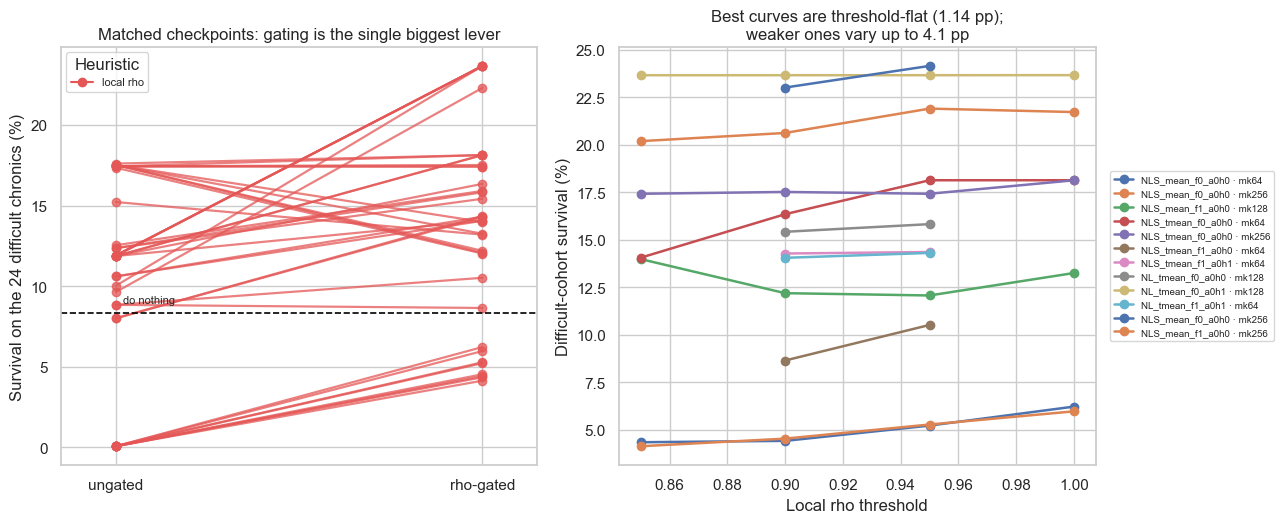

#### Threshold sensitivity per completed curve

Sorted by best difficult-cohort survival. The pattern is that the *good* configurations are the *insensitive* ones: threshold tuning is not where the remaining wins are.

thresholds    lo    hi  spread_pp
adaptation      variant           mk                                    
MAPPO fine-tune NLS_mean_f0_a0h0  256           2 23.01 24.15       1.14
bus14 zero-shot NL_tmean_f0_a0h1  128           4 23.66 23.67       0.00
MAPPO fine-tune NLS_mean_f1_a0h0  256           4 20.19 21.91       1.71
bus14 zero-shot NLS_tmean_f0_a0h0 64            4 14.05 18.13       4.08
                                  256           4 17.42 18.13       0.71
                NL_tmean_f0_a0h0  128           2 15.42 15.82       0.40
                NLS_tmean_f1_a0h1 64            2 14.27 14.35       0.08
                NL_tmean_f1_a0h1  64            2 14.05 14.30       0.26
                NLS_mean_f1_a0h0  128           4 12.06 13.98       1.92
                NLS_tmean_f1_a0h0 64            2  8.64 10.51       1.87
                NLS_mean_f0_a0h0  64            4  4.33  6.21       1.88
                                  256           4  4.12  5.96       1.84

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.4))

for row in matched.itertuples():
    axes[0].plot(
        [0, 1], [row.ungated_hard_pct, row.hard_pct],
        marker="o", linewidth=1.6, alpha=0.75,
        color=HEURISTIC_COLORS.get(row.heuristic, "#888888"),
    )
axes[0].axhline(DN_HARD, color="black", linestyle="--", linewidth=1.2)
axes[0].text(0.02, DN_HARD + 0.6, "do nothing", fontsize=8)
axes[0].set_xticks([0, 1], ["ungated", "rho-gated"])
axes[0].set_xlim(-0.15, 1.15)
axes[0].set(ylabel=f"Survival on the {N_HARD} difficult chronics (%)",
            title="Matched checkpoints: gating is the single biggest lever")
present = [h for h in HEURISTIC_ORDER if h in set(matched["heuristic"])]
handles = [plt.Line2D([], [], color=HEURISTIC_COLORS[h], marker="o", label=h) for h in present]
axes[0].legend(handles=handles, title="Heuristic", fontsize=8, loc="upper left")

threshold_curves = runs.loc[
    (runs["heuristic"] == "local rho") & runs["hard_pct"].notna()
]
curve_spread = (
    threshold_curves.groupby(["adaptation", "variant", "mk"], observed=True)
    .agg(thresholds=("rho", "nunique"), lo=("hard_pct", "min"), hi=("hard_pct", "max"))
)
curve_spread = curve_spread.loc[curve_spread["thresholds"] >= 2]
curve_spread["spread_pp"] = curve_spread["hi"] - curve_spread["lo"]
leader_spread = curve_spread.sort_values("hi", ascending=False).iloc[0]

for (init, variant, mk), group in threshold_curves.groupby(
    ["adaptation", "variant", "mk"], observed=True
):
    if group["rho"].nunique() < 2:
        continue
    group = group.sort_values("rho")
    axes[1].plot(group["rho"], group["hard_pct"], marker="o", linewidth=1.8,
                 label=f"{variant} · mk{int(mk)}")
axes[1].set(
    xlabel="Local rho threshold", ylabel="Difficult-cohort survival (%)",
    title=(
        f"Best curves are threshold-flat ({leader_spread['spread_pp']:.2f} pp);\n"
        f"weaker ones vary up to {curve_spread['spread_pp'].max():.1f} pp"
    ),
)
axes[1].legend(fontsize=7, loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()
save_figure(fig, "04_heuristic")
plt.show()

display(Markdown(
    "#### Threshold sensitivity per completed curve\n\n"
    "Sorted by best difficult-cohort survival. The pattern is that the *good* "
    "configurations are the *insensitive* ones: threshold tuning is not where the "
    "remaining wins are."
))
display(curve_spread.sort_values("hi", ascending=False))

## 7. Factor 3 — the adaptation route

Four ways to obtain a WCCI policy from the shared-candidate architecture, differing
in **what signal the target-grid gradient comes from**:

| route | target-grid signal | source of supervision |
|---|---|---|
| **bus14 zero-shot** | none | — |
| **MAPPO fine-tune** | WCCI reward | PPO return, warm-started from the bus14 actor |
| **BC on greedy labels** | WCCI expert actions | supervised imitation of the one-step simulator oracle |
| **MAPPO scratch** | WCCI reward | PPO return from random init |

The distinction between the two *fine-tuning* routes matters more than it looks, and
§7b is devoted to it. Budgets differ a lot (see `checkpoint_step`), so this section
compares *what was run*, not converged variants of each regime.

> `checkpoint_step` is not comparable across routes. The BC checkpoints inherit the
> global step of the bus14 actor they were adapted from (14.9 M), which counts bus14
> PPO steps, **not** BC gradient steps — BC trained for 12 epochs over ~1 496
> dangerous states.

In [62]:
init_summary = (
    runs.groupby(["adaptation", "heuristic"], as_index=False, observed=True)
    .agg(
        runs=("key", "size"),
        scored=("hard_pct", "count"),
        hard_best=("hard_pct", "max"),
        hard_median=("hard_pct", "median"),
        rescues_best=("hard_rescues", "max"),
        overall_best=("overall_pct", "max"),
        overall_median=("overall_pct", "median"),
        capture_hard_best=("capture_hard_pct", "max"),
    )
)
display(init_summary)

mk64 = runs.loc[runs["mk"] == 64].copy()
display(Markdown(
    "#### Head-to-head at a fixed action space (mk64)\n\n"
    "mk64 is the only cap where all three adaptations were evaluated — but the "
    "fine-tuned and scratch mk64 runs are exactly the ones missing per-episode "
    "artifacts, so this table **must** be read on `overall_pct`. `hard_pct` is shown "
    "where it exists and is blank otherwise. Best three runs per cell."
))
display(
    mk64.sort_values("overall_pct", ascending=False)
    .groupby(["adaptation", "heuristic"], observed=True)
    .head(3)[DIGEST_COLUMNS]
    .sort_values(["adaptation", "overall_pct"], ascending=[True, False])
)
mk64_best = (
    mk64.sort_values("overall_pct", ascending=False)
    .groupby("adaptation", observed=True).head(1)
)
mk64_span = mk64_best["overall_pct"].max() - mk64_best["overall_pct"].min()
display(Markdown(
    f"The best run of each adaptation at mk64 spans only **{mk64_span:.2f} pp** "
    "of overall survival. Since 26 of 50 chronics are free and these runs keep nearly "
    "all of them, that is roughly twice as much on the difficult cohort — still small "
    "against a paired-bootstrap CI tens of points wide, on single seeds and very "
    "different budgets. **These three adaptations are not separated by this evidence.**"
))

,adaptation,heuristic,runs,scored,hard_best,hard_median,rescues_best,overall_best,overall_median,capture_hard_best
0,bus14 zero-shot,none,80,80,17.60,1.08,3.00,59.75,1.03,15.48
1,bus14 zero-shot,local rho,38,38,23.67,14.29,4.00,63.36,58.80,25.61
2,MAPPO fine-tune,none,5,0,NaN,NaN,NaN,61.03,59.49,NaN
3,MAPPO fine-tune,global rho,2,2,18.19,18.18,3.00,60.73,60.73,11.37
4,MAPPO fine-tune,local rho,11,6,24.15,21.81,4.00,63.65,62.01,18.26
5,BC on greedy labels,none,1,0,NaN,NaN,NaN,54.02,54.02,NaN
6,BC on greedy labels,local rho,1,0,NaN,NaN,NaN,62.62,62.62,NaN
7,MAPPO scratch,none,1,0,NaN,NaN,NaN,63.16,63.16,NaN


#### Head-to-head at a fixed action space (mk64)

mk64 is the only cap where all three adaptations were evaluated — but the fine-tuned and scratch mk64 runs are exactly the ones missing per-episode artifacts, so this table **must** be read on `overall_pct`. `hard_pct` is shown where it exists and is blank otherwise. Best three runs per cell.

,adaptation,mk,heuristic,rho,variant,checkpoint_step,overall_pct,hard_pct,hard_rescues,easy_kept,capture_hard_pct,capture_overall_pct
125,bus14 zero-shot,64,local rho,0.95,NL_tmean_f0_a0h1,14598144,62.71,22.30,4.00,26.00,23.45,25.93
116,bus14 zero-shot,64,local rho,1.00,NLS_tmean_f0_a0h0,14929920,60.70,18.13,3.00,26.00,16.45,18.18
115,bus14 zero-shot,64,local rho,0.95,NLS_tmean_f0_a0h0,14929920,60.70,18.13,3.00,26.00,16.44,18.18
76,bus14 zero-shot,64,none,NaN,NL_tmean_f0_a0h0,11778048,58.00,12.53,1.00,25.00,7.04,7.73
34,bus14 zero-shot,64,none,NaN,NLS_mean_f1_a0h0,14929920,57.77,17.35,1.00,23.00,15.13,6.83
36,bus14 zero-shot,64,none,NaN,NLS_tmean_f0_a0h0,14929920,57.69,11.86,1.00,25.00,5.92,6.51
88,MAPPO fine-tune,64,local rho,0.95,NLS_mean_f0_a0h0,4976640,63.65,NaN,NaN,NaN,NaN,29.58
89,MAPPO fine-tune,64,local rho,0.95,NLS_mean_f0_a0h1,4976640,62.01,NaN,NaN,NaN,NaN,23.25
91,MAPPO fine-tune,64,local rho,0.95,NLS_mean_f1_a0h1,4976640,61.91,NaN,NaN,NaN,NaN,22.85
85,MAPPO fine-tune,64,none,NaN,NLS_mean_f1_a0h0,4976640,61.03,NaN,NaN,NaN,NaN,19.46


The best run of each adaptation at mk64 spans only **1.02 pp** of overall survival. Since 26 of 50 chronics are free and these runs keep nearly all of them, that is roughly twice as much on the difficult cohort — still small against a paired-bootstrap CI tens of points wide, on single seeds and very different budgets. **These three adaptations are not separated by this evidence.**

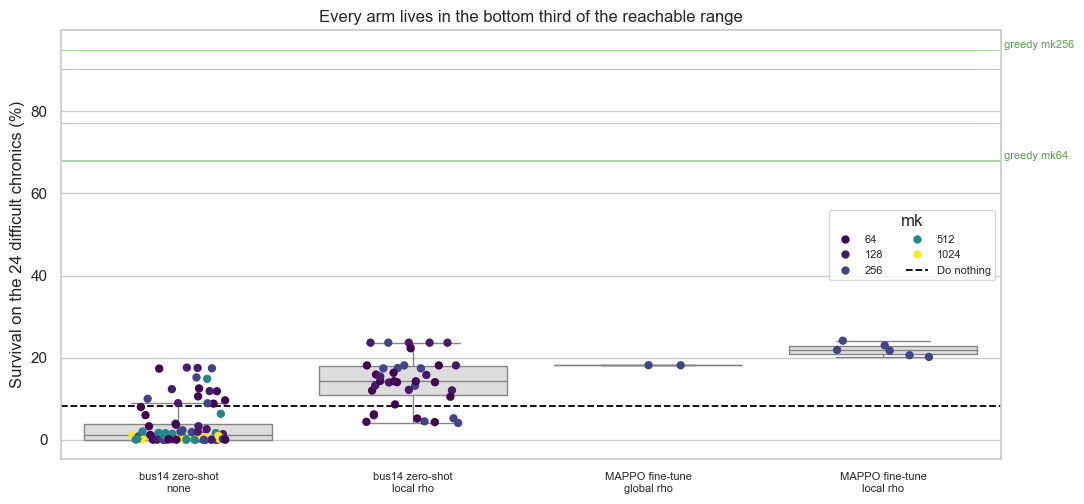

In [63]:
fig, ax = plt.subplots(figsize=(11.0, 5.2))
plot_data = runs.dropna(subset=["hard_pct"]).copy()
plot_data["cell"] = (
    plot_data["adaptation"].astype(str) + "\n" + plot_data["heuristic"].astype(str)
)
cell_order = [
    f"{init}\n{heur}" for init in ADAPTATION_ORDER for heur in HEURISTIC_ORDER
    if f"{init}\n{heur}" in set(plot_data["cell"])
]
sns.boxplot(data=plot_data, x="cell", y="hard_pct", order=cell_order,
            showfliers=False, color="#DDDDDD", ax=ax)
sns.stripplot(data=plot_data, x="cell", y="hard_pct", order=cell_order,
              hue="mk", palette="viridis", size=6, jitter=0.2, ax=ax)
ax.axhline(DN_HARD, color="black", linestyle="--", linewidth=1.3, label="Do nothing")
for mk in sorted(set(plot_data["mk"].dropna())):
    ax.axhline(GREEDY_HARD[mk], color="#54A24B", linewidth=0.8, alpha=0.45)
ax.text(len(cell_order) - 0.5, GREEDY_HARD[64], " greedy mk64", color="#54A24B", fontsize=8, va="bottom")
ax.text(len(cell_order) - 0.5, GREEDY_HARD[256], " greedy mk256", color="#54A24B", fontsize=8, va="bottom")
ax.set(xlabel="", ylabel=f"Survival on the {N_HARD} difficult chronics (%)",
       title="Every arm lives in the bottom third of the reachable range")
ax.legend(title="mk", fontsize=8, ncol=2)
ax.tick_params(axis="x", labelsize=8)
fig.tight_layout()
save_figure(fig, "05_adaptation")
plt.show()

## 7b. MAPPO fine-tuning versus behaviour cloning

Both routes spend target-grid gradient steps on the same transferred actor, but they
optimise different things, and the notebook's own ceiling makes the contrast concrete:

* **MAPPO fine-tune** maximises WCCI return with PPO. It sees every state the policy
  visits, safe and dangerous alike, and has to discover *both* what to do and when.
* **BC on greedy labels** is supervised imitation of the **one-step simulator greedy** —
  the exact oracle used as the denominator of `capture_hard_%` throughout this notebook.
  Labels are collected on the WCCI **training** chronics only, at states whose global
  max rho is ≥ 0.90: every candidate is simulated, the action with the lowest next-step
  max rho is kept if it beats do-nothing by ≥ 0.001, otherwise the label is
  *do nothing*. Unconcerned agents are always labelled do-nothing.

Two consequences follow, and both show up in the numbers.

1. For a BC model, `capture_hard_%` is not a loose analogy — it is **teacher-reproduction
   fidelity**. The student is being scored against the very policy it was trained to copy.
2. BC is trained **only on dangerous states**. It has no supervision for the safe states
   that make up most of an episode, so its behaviour there is undefined. That predicts a
   specific and testable failure: BC should be unusually bad ungated and unusually good
   once a rho gate restricts it to the regime it was trained on.

In [64]:
bc_runs = runs.loc[runs["adaptation"] == "BC on greedy labels"]
if bc_runs.empty:
    display(Markdown("_No behaviour-cloning results are currently downloaded._"))
else:
    display(Markdown(
        f"**{len(bc_runs)} behaviour-cloning evaluation(s) downloaded** — "
        f"recipe(s): `{'`, `'.join(sorted(set(bc_runs['adaptation_detail'])))}`; "
        f"architecture(s): `{'`, `'.join(sorted(set(bc_runs['variant'])))}`; "
        f"action space(s): {', '.join(f'mk{int(m)}' for m in sorted(set(bc_runs['mk'])))}."
    ))
    display(bc_runs[[
        "run", "adaptation_detail", "variant", "mk", "heuristic", "rho",
        "overall_pct", "hard_pct", "capture_overall_pct", "has_episodes",
    ]])

# Controlled comparison: hold architecture and action space fixed, vary the route.
route_cells = (
    runs.groupby(["variant", "mk"], observed=True)
    .agg(
        routes=("adaptation", "nunique"),
        has_bc=("adaptation", lambda s: "BC on greedy labels" in set(s)),
        gate_settings=("heuristic", "nunique"),
    )
    .reset_index()
)
best_cell_key = route_cells.sort_values(
    ["has_bc", "routes", "gate_settings"], ascending=False
).iloc[0]
controlled = runs.loc[
    (runs["variant"] == best_cell_key["variant"]) & (runs["mk"] == best_cell_key["mk"])
].copy()
display(Markdown(
    f"### Controlled comparison — `{best_cell_key['variant']}` at "
    f"mk{int(best_cell_key['mk'])}\n\n"
    f"The architecture × action-space cell evaluated under "
    f"**{int(best_cell_key['routes'])} adaptation routes**"
    + ("" if best_cell_key["has_bc"] else " *(no BC run in this cell)*")
    + ". Same architecture, same candidate set, same seed — the only things that "
    "change are where the target-grid gradient came from and whether a deployment "
    "gate is applied. This is the cleanest evidence in the notebook on MAPPO versus BC."
))
display(
    controlled.sort_values(["adaptation", "heuristic"])[[
        "adaptation", "adaptation_detail", "heuristic", "rho",
        "overall_pct", "hard_pct", "hard_rescues", "easy_kept", "has_episodes",
    ]]
)

gate_effect = controlled.pivot_table(
    index=["adaptation"], columns="heuristic", values="overall_pct",
    aggfunc="max", observed=True,
)
if {"none", "local rho"} <= set(gate_effect.columns):
    gate_effect["gate_gain_pp"] = gate_effect["local rho"] - gate_effect["none"]
display(Markdown(
    "#### What the deployment gate is worth to each route (overall survival)\n\n"
    f"Do-nothing sits at `{DN_OVERALL:.2f}%`. A route below that line is actively "
    "harmful in the configuration shown."
))
display(gate_effect)

**2 behaviour-cloning evaluation(s) downloaded** — recipe(s): `direct from bus14`; architecture(s): `NLS_mean_f1_a0h0`; action space(s): mk64.

,run,adaptation_detail,variant,mk,heuristic,rho,overall_pct,hard_pct,capture_overall_pct,has_episodes
80,bcg_direct_bus14_cons1496_e12_lr30_bal040_w3_a...,direct from bus14,NLS_mean_f1_a0h0,64,none,NaN,54.02,NaN,-7.67,False
81,bcg_direct_bus14_cons1496_e12_lr30_bal040_w3_a...,direct from bus14,NLS_mean_f1_a0h0,64,local rho,0.95,62.62,NaN,25.62,False


### Controlled comparison — `NLS_mean_f1_a0h0` at mk64

The architecture × action-space cell evaluated under **3 adaptation routes**. Same architecture, same candidate set, same seed — the only things that change are where the target-grid gradient came from and whether a deployment gate is applied. This is the cleanest evidence in the notebook on MAPPO versus BC.

,adaptation,adaptation_detail,heuristic,rho,overall_pct,hard_pct,hard_rescues,easy_kept,has_episodes
34,bus14 zero-shot,no target-grid gradient,none,NaN,57.77,17.35,1.00,23.00,True
119,bus14 zero-shot,no target-grid gradient,local rho,0.95,53.52,12.02,0.00,22.00,True
85,MAPPO fine-tune,warm start from bus14,none,NaN,61.03,NaN,NaN,NaN,False
90,MAPPO fine-tune,warm start from bus14,local rho,0.95,60.92,NaN,NaN,NaN,False
80,BC on greedy labels,direct from bus14,none,NaN,54.02,NaN,NaN,NaN,False
81,BC on greedy labels,direct from bus14,local rho,0.95,62.62,NaN,NaN,NaN,False


#### What the deployment gate is worth to each route (overall survival)

Do-nothing sits at `56.00%`. A route below that line is actively harmful in the configuration shown.

heuristic,none,local rho,gate_gain_pp
adaptation,,,
bus14 zero-shot,57.77,53.52,-4.25
MAPPO fine-tune,61.03,60.92,-0.12
BC on greedy labels,54.02,62.62,8.61


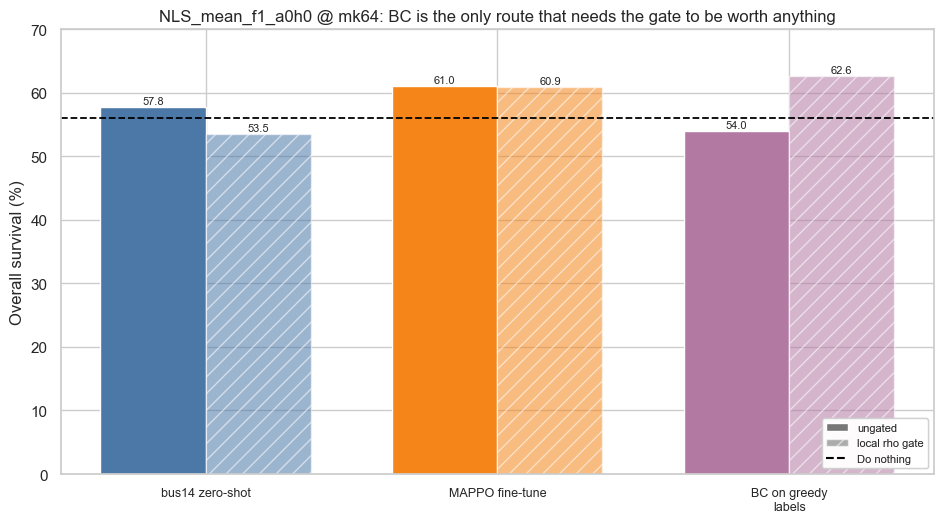

In [65]:
if bool(best_cell_key["has_bc"]) and len(controlled) >= 4:
    order = [a for a in ADAPTATION_ORDER if a in set(controlled["adaptation"])]
    fig, ax = plt.subplots(figsize=(9.6, 5.4))
    width = 0.36
    positions = np.arange(len(order))
    for offset, heuristic, hatch in ((-width / 2, "none", None), (width / 2, "local rho", "//")):
        values = [
            controlled.loc[
                (controlled["adaptation"] == route) & (controlled["heuristic"] == heuristic),
                "overall_pct",
            ].max()
            for route in order
        ]
        bars = ax.bar(
            positions + offset, values, width,
            color=[ADAPTATION_COLORS[r] for r in order],
            alpha=1.0 if heuristic == "none" else 0.55, hatch=hatch,
            edgecolor="white", linewidth=1.0,
            label="_nolegend_",
        )
        for bar, value in zip(bars, values):
            if not np.isnan(value):
                ax.text(bar.get_x() + bar.get_width() / 2, value + 0.5,
                        f"{value:.1f}", ha="center", fontsize=8)
    ax.axhline(DN_OVERALL, color="black", linestyle="--", linewidth=1.3, label="Do nothing")
    ax.add_artist(ax.legend(
        handles=[
            plt.Rectangle((0, 0), 1, 1, facecolor="#777777", label="ungated"),
            plt.Rectangle((0, 0), 1, 1, facecolor="#777777", alpha=0.55, hatch="//",
                          edgecolor="white", label="local rho gate"),
            plt.Line2D([], [], color="black", linestyle="--", label="Do nothing"),
        ],
        loc="lower right", fontsize=8,
    ))
    ax.set_xticks(
        positions,
        [textwrap.fill(route, 16) for route in order],
        fontsize=9,
    )
    ax.set(ylabel="Overall survival (%)",
           ylim=(0, max(70, controlled["overall_pct"].max() + 6)),
           title=f"{best_cell_key['variant']} @ mk{int(best_cell_key['mk'])}: "
                 "BC is the only route that needs the gate to be worth anything")
    fig.tight_layout()
    save_figure(fig, "06b_mappo_vs_bc")
    plt.show()

In [66]:
if not bc_runs.empty:
    bc_best = bc_runs.sort_values("overall_pct", ascending=False).iloc[0]
    bc_ungated = bc_runs.loc[bc_runs["heuristic"] == "none", "overall_pct"].max()
    mk = int(bc_best["mk"])
    lines = [
        "#### Reading the behaviour-cloning arm",
        "",
        f"- Ungated, BC reaches **{bc_ungated:.2f}%** overall — "
        f"**{bc_ungated - DN_OVERALL:+.2f} pp against do-nothing**, and "
        f"{bc_ungated - runs.loc[(runs['adaptation'] == 'bus14 zero-shot') & (runs['variant'] == bc_best['variant']) & (runs['mk'] == mk) & (runs['heuristic'] == 'none'), 'overall_pct'].max():+.2f} pp "
        "against the un-adapted bus14 actor it was distilled from.",
        f"- Gated at local rho {bc_best['rho']:.2f} the same checkpoint reaches "
        f"**{bc_best['overall_pct']:.2f}%** — a **{bc_best['overall_pct'] - bc_ungated:+.2f} pp** "
        "swing from the deployment gate alone, by far the largest gate effect of any route.",
        f"- That is exactly the predicted signature of dangerous-state-only supervision: "
        f"the labels only exist above rho 0.90, and the gate is what keeps the policy "
        f"inside that regime at deployment. **For a BC model the gate is not a "
        f"deployment tweak — it is part of the model's contract.**",
        "",
        f"- Teacher gap: the greedy oracle this student was trained to copy reaches "
        f"`{GREEDY_OVERALL[mk]:.2f}%` overall at mk{mk}, so even gated the student "
        f"recovers **{bc_best['capture_overall_pct']:.1f}%** of its teacher's margin "
        "over do-nothing.",
    ]
    display(Markdown("\n".join(lines)))

#### Reading the behaviour-cloning arm

- Ungated, BC reaches **54.02%** overall — **-1.98 pp against do-nothing**, and -3.75 pp against the un-adapted bus14 actor it was distilled from.
- Gated at local rho 0.95 the same checkpoint reaches **62.62%** — a **+8.61 pp** swing from the deployment gate alone, by far the largest gate effect of any route.
- That is exactly the predicted signature of dangerous-state-only supervision: the labels only exist above rho 0.90, and the gate is what keeps the policy inside that regime at deployment. **For a BC model the gate is not a deployment tweak — it is part of the model's contract.**

- Teacher gap: the greedy oracle this student was trained to copy reaches `81.85%` overall at mk64, so even gated the student recovers **25.6%** of its teacher's margin over do-nothing.

## 8. Factor 4 — architecture, and whether bus14 skill predicts WCCI skill

Four binary/architectural choices vary inside the shared-candidate design:
`family` (NL / NLS-scaled), `pool` (mean / typed-mean over candidate embeddings),
`features` (`f0` / `f1`, candidate features fed to the scorer) and `head`
(`a0h0` / `a0h1`, explicit do-nothing head). Marginals are computed on the complete
80-run zero-shot ungated grid.

The marginals are misleading on their own, so the pooling × features cross-tab
follows: the failure is an **interaction**, not a main effect. A sizeable minority
of the zero-shot grid does not merely underperform — it collapses to near-zero
survival, failing within a handful of steps.

The last table asks the question that matters for the whole methodology: **does a
better bus14 model transfer better?** If bus14 test survival barely correlates with
WCCI difficult-cohort survival, then selecting checkpoints on the source grid is
not selecting for transfer at all.

In [67]:
factor_rows = []
for factor in ["family", "pool", "features", "head"]:
    grouped = zero_ungated.groupby(factor, observed=True).agg(
        runs=("key", "size"),
        hard_mean=("hard_pct", "mean"),
        hard_best=("hard_pct", "max"),
        overall_mean=("overall_pct", "mean"),
        rescues_mean=("hard_rescues", "mean"),
        easy_kept_mean=("easy_kept", "mean"),
    )
    for level, values in grouped.iterrows():
        factor_rows.append({"factor": factor, "level": str(level), **values.to_dict()})
architecture_marginals = pd.DataFrame(factor_rows)
display(architecture_marginals)

pool_by_features = zero_ungated.pivot_table(
    index="pool", columns="features", values="hard_pct",
    aggfunc=["mean", "max"], observed=True,
)
collapsed = zero_ungated.loc[zero_ungated["hard_pct"] < 0.5]
display(Markdown(
    "#### Pooling × candidate features — the interaction, not the marginals\n\n"
    f"**{len(collapsed)} of {len(zero_ungated)} zero-shot ungated runs collapse outright** "
    f"(difficult-cohort survival below 0.5 %, i.e. the grid falls within a handful of steps). "
    f"They come from **{collapsed['variant'].nunique()} architecture variants**: "
    f"`{'`, `'.join(sorted(collapsed['variant'].unique()))}`."
))
display(pool_by_features)
display(
    zero_ungated.groupby(["pool", "features"], as_index=False, observed=True)
    .agg(runs=("key", "size"),
         collapsed_runs=("hard_pct", lambda s: int((s < 0.5).sum())),
         hard_mean=("hard_pct", "mean"), hard_best=("hard_pct", "max"))
)

variant_ranking = (
    zero_ungated.groupby(["family", "variant"], as_index=False, observed=True)
    .agg(
        caps=("mk", "nunique"),
        hard_mean_over_caps=("hard_pct", "mean"),
        hard_best=("hard_pct", "max"),
        best_cap=("mk", lambda s: int(zero_ungated.loc[s.index].sort_values("hard_pct").iloc[-1]["mk"])),
    )
    .sort_values("hard_mean_over_caps", ascending=False)
)
display(Markdown("#### Architecture variants ranked by mean difficult-cohort survival across all five caps"))
display(variant_ranking)

,factor,level,runs,hard_mean,hard_best,overall_mean,rescues_mean,easy_kept_mean
0,family,NL,40.00,3.14,12.53,14.17,0.10,5.25
1,family,NLS,40.00,3.79,17.60,17.24,0.30,6.88
2,pool,mean,40.00,2.31,17.52,7.22,0.12,2.73
3,pool,tmean,40.00,4.62,17.60,24.19,0.28,9.40
4,features,0,40.00,3.00,17.60,14.80,0.28,5.90
5,features,1,40.00,3.93,17.52,16.61,0.12,6.22
6,head,0,40.00,4.45,17.60,16.67,0.35,6.50
7,head,1,40.00,2.48,11.89,14.75,0.05,5.62


#### Pooling × candidate features — the interaction, not the marginals

**33 of 80 zero-shot ungated runs collapse outright** (difficult-cohort survival below 0.5 %, i.e. the grid falls within a handful of steps). They come from **10 architecture variants**: `NLS_mean_f0_a0h0`, `NLS_mean_f0_a0h1`, `NLS_mean_f1_a0h0`, `NLS_tmean_f0_a0h1`, `NLS_tmean_f1_a0h0`, `NLS_tmean_f1_a0h1`, `NL_mean_f0_a0h0`, `NL_mean_f0_a0h1`, `NL_mean_f1_a0h1`, `NL_tmean_f1_a0h1`.

mean        max      
features    0    1     0     1
pool                          
mean     0.06 4.57  0.07 17.52
tmean    5.95 3.30 17.60 10.60

,pool,features,runs,collapsed_runs,hard_mean,hard_best
0,mean,0,20,20,0.06,0.07
1,mean,1,20,6,4.57,17.52
2,tmean,0,20,1,5.95,17.60
3,tmean,1,20,6,3.30,10.60


#### Architecture variants ranked by mean difficult-cohort survival across all five caps

,family,variant,caps,hard_mean_over_caps,hard_best,best_cap
10,NLS,NLS_mean_f1_a0h0,5,13.07,17.52,128
12,NLS,NLS_tmean_f0_a0h0,5,9.66,17.60,128
7,NL,NL_tmean_f1_a0h1,5,7.00,10.60,64
5,NL,NL_tmean_f0_a0h1,5,6.93,11.89,128
4,NL,NL_tmean_f0_a0h0,5,6.15,12.53,64
2,NL,NL_mean_f1_a0h0,5,2.75,6.04,64
15,NLS,NLS_tmean_f1_a0h1,5,2.29,8.00,64
11,NLS,NLS_mean_f1_a0h1,5,2.29,3.33,128
6,NL,NL_tmean_f1_a0h0,5,2.04,3.72,64
14,NLS,NLS_tmean_f1_a0h0,5,1.85,8.83,64


#### Source skill vs transferred skill — Pearson r = **-0.01** across 16 architecture variants

,variant,wcci_hard_mean,wcci_hard_best,wcci_overall_mean,bus14_group,bus14_pct,bus14_episodes
2,NLS_mean_f1_a0h0,13.07,17.52,46.13,NLS_cas_hl_izar_shared,99.94,201
4,NLS_tmean_f0_a0h0,9.66,17.60,44.15,NLS_cas_hl_izar_shared,100.00,201
15,NL_tmean_f1_a0h1,7.00,10.60,29.71,NL_cas_hl_shared,99.24,201
13,NL_tmean_f0_a0h1,6.93,11.89,50.57,NL_cas_hl_shared,64.83,201
12,NL_tmean_f0_a0h0,6.15,12.53,21.77,NL_cas_hl_shared,78.74,201
10,NL_mean_f1_a0h0,2.75,6.04,9.62,NL_cas_hl_shared,97.73,201
7,NLS_tmean_f1_a0h1,2.29,8.00,34.09,NLS_cas_hl_izar_shared,93.40,201
3,NLS_mean_f1_a0h1,2.29,3.33,1.41,NLS_cas_hl_izar_shared,97.55,201
14,NL_tmean_f1_a0h0,2.04,3.72,1.22,NL_cas_hl_shared,98.38,201
6,NLS_tmean_f1_a0h0,1.85,8.83,10.34,NLS_cas_hl_izar_shared,99.37,201


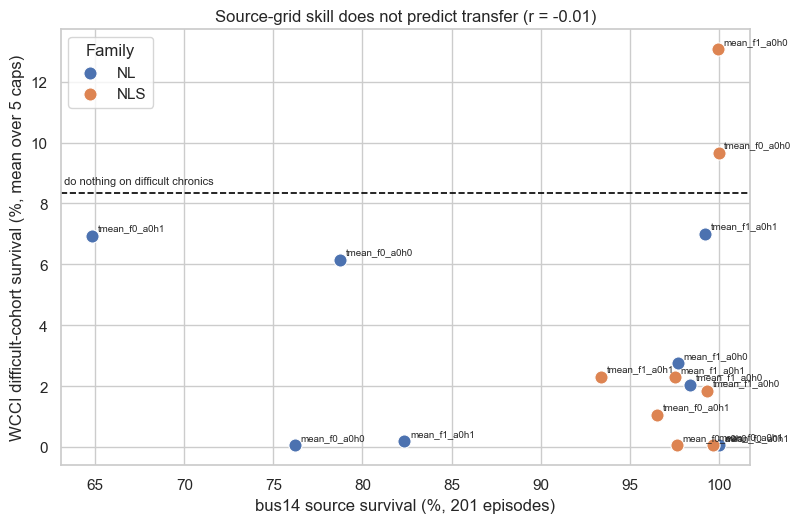

In [68]:
bus14_rows = []
for result_path in sorted(BUS14_RESULT_ROOT.rglob("*.json")):
    payload = load_json(result_path)
    stem = Path(payload.get("checkpoint", result_path.stem)).stem
    pool, features, head = parse_variant(stem, result_path.stem)
    family = "NLS" if "_NLS_" in stem else ("NL" if "_NL_" in stem else "other")
    bus14_rows.append({
        "variant": f"{family}_{pool}_f{features}_a0h{head}",
        "bus14_group": result_path.parent.name,
        "bus14_pct": payload.get("survival_percent"),
        "bus14_episodes": payload.get("eval_episodes"),
    })
bus14 = pd.DataFrame(bus14_rows)
# The WCCI zero-shot arm transfers the izar-scaled NLS checkpoints.
bus14 = (
    bus14.loc[bus14["bus14_group"].isin({"NL_cas_hl_shared", "NLS_cas_hl_izar_shared"})]
    .drop_duplicates(subset="variant")
)

transfer_link = (
    zero_ungated.groupby("variant", as_index=False, observed=True)
    .agg(wcci_hard_mean=("hard_pct", "mean"), wcci_hard_best=("hard_pct", "max"),
         wcci_overall_mean=("overall_pct", "mean"))
    .merge(bus14, on="variant", how="inner")
)
correlation = transfer_link[["bus14_pct", "wcci_hard_mean"]].corr().iloc[0, 1]
display(Markdown(
    f"#### Source skill vs transferred skill — Pearson r = **{correlation:+.2f}** "
    f"across {len(transfer_link)} architecture variants"
))
display(transfer_link.sort_values("wcci_hard_mean", ascending=False))

fig, ax = plt.subplots(figsize=(8.2, 5.4))
for family, group in transfer_link.groupby(transfer_link["variant"].str.split("_").str[0]):
    ax.scatter(group["bus14_pct"], group["wcci_hard_mean"], s=90, label=family,
               edgecolor="white", linewidth=0.8)
for row in transfer_link.itertuples():
    ax.annotate(row.variant.split("_", 1)[1], (row.bus14_pct, row.wcci_hard_mean),
                xytext=(4, 4), textcoords="offset points", fontsize=7)
ax.axhline(DN_HARD, color="black", linestyle="--", linewidth=1.2)
ax.text(ax.get_xlim()[0], DN_HARD + 0.3, " do nothing on difficult chronics", fontsize=8)
ax.set(xlabel="bus14 source survival (%, 201 episodes)",
       ylabel=f"WCCI difficult-cohort survival (%, mean over 5 caps)",
       title=f"Source-grid skill does not predict transfer (r = {correlation:+.2f})")
ax.legend(title="Family")
fig.tight_layout()
save_figure(fig, "06_architecture_transfer")
plt.show()

## 9. The digest matrix

Best run per (adaptation × heuristic × action space) cell. This is the table to
read first: it collapses 100+ evaluations into the question *"given a training
regime, an action space and a gating choice, what is the best that was achieved?"*
Empty cells were never evaluated.

In [69]:
def best_cell(frame, value):
    scoped = frame.dropna(subset=[value])
    if scoped.empty:
        return pd.DataFrame()
    return scoped.pivot_table(
        index=["adaptation", "heuristic"], columns="mk",
        values=value, aggfunc="max", observed=True,
    )


for value, title in (
    ("hard_pct", f"Best difficult-cohort survival (%) — do-nothing = {DN_HARD:.2f}"),
    ("capture_hard_pct", "Best share of greedy headroom captured on difficult chronics (%)"),
    ("hard_rescues", f"Most difficult chronics carried to the end (out of {N_HARD})"),
    ("overall_pct", f"Best overall survival (%) — do-nothing = {DN_OVERALL:.2f}"),
):
    display(Markdown(f"#### {title}"))
    display(best_cell(runs, value))

display(Markdown(f"#### Greedy oracle reference"))
display(greedy_ceiling.set_index("mk").T)

#### Best difficult-cohort survival (%) — do-nothing = 8.34

mk                          64    128   256   512   1024
adaptation      heuristic                               
bus14 zero-shot none       17.35 17.60 17.43 14.87  1.20
                local rho  22.30 23.67 23.66   NaN   NaN
MAPPO fine-tune global rho   NaN   NaN 18.19   NaN   NaN
                local rho    NaN   NaN 24.15   NaN   NaN

#### Best share of greedy headroom captured on difficult chronics (%)

mk                          64    128   256   512   1024
adaptation      heuristic                               
bus14 zero-shot none       15.13 15.48 10.50  9.49 -8.73
                local rho  23.45 25.61 17.70   NaN   NaN
MAPPO fine-tune global rho   NaN   NaN 11.37   NaN   NaN
                local rho    NaN   NaN 18.26   NaN   NaN

#### Most difficult chronics carried to the end (out of 24)

mk                          64    128   256   512   1024
adaptation      heuristic                               
bus14 zero-shot none        1.00  3.00  3.00  1.00  0.00
                local rho   4.00  4.00  4.00   NaN   NaN
MAPPO fine-tune global rho   NaN   NaN  3.00   NaN   NaN
                local rho    NaN   NaN  4.00   NaN   NaN

#### Best overall survival (%) — do-nothing = 56.00

mk                              64    128   256   512   1024
adaptation          heuristic                               
bus14 zero-shot     none       58.00 58.98 59.75 56.49 39.75
                    local rho  62.71 63.36 63.36   NaN   NaN
MAPPO fine-tune     none       61.03   NaN   NaN   NaN   NaN
                    global rho   NaN   NaN 60.73   NaN   NaN
                    local rho  63.65   NaN 63.59   NaN   NaN
BC on greedy labels none       54.02   NaN   NaN   NaN   NaN
                    local rho  62.62   NaN   NaN   NaN   NaN
MAPPO scratch       none       63.16   NaN   NaN   NaN   NaN

#### Greedy oracle reference

mk,32,64,128,256,512,1024
greedy_overall_pct,67.89,81.85,84.73,97.56,88.27,95.28
greedy_hard_pct,33.11,67.88,68.19,94.92,77.12,90.16
greedy_hard_rescues,4.00,9.00,12.00,20.00,16.00,19.00
greedy_easy_kept,26.00,23.00,26.00,26.00,25.00,26.00


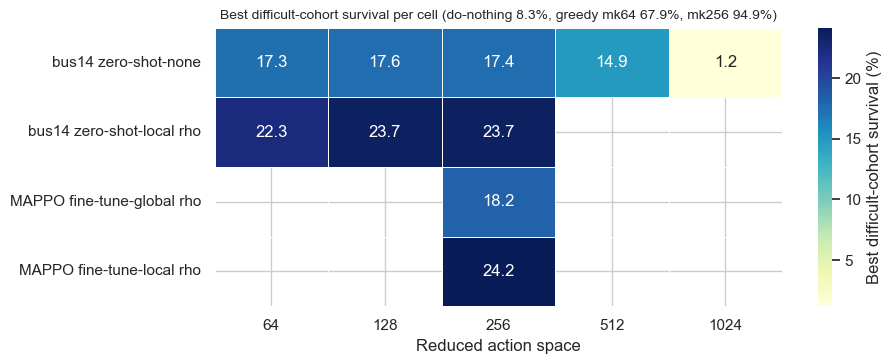

In [70]:
matrix = best_cell(runs, "hard_pct")
fig, ax = plt.subplots(figsize=(9.5, 3.8))
sns.heatmap(
    matrix, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.6, linecolor="white",
    cbar_kws={"label": "Best difficult-cohort survival (%)"}, ax=ax,
)
ax.set(xlabel="Reduced action space", ylabel="")
ax.set_title(
    f"Best difficult-cohort survival per cell "
    f"(do-nothing {DN_HARD:.1f}%, greedy mk64 {GREEDY_HARD[64]:.1f}%, mk256 {GREEDY_HARD[256]:.1f}%)",
    fontsize=10,
)
fig.tight_layout()
save_figure(fig, "07_digest_matrix")
plt.show()

## 10. Where the survival actually comes from

A high difficult-cohort mean can be produced two ways: broad partial improvement
across many chronics, or a handful of complete rescues. They imply very different
things about the policy, so this section decomposes the best system in each
adaptation and puts it next to the greedy oracle chronic by chronic.

In [71]:
best_per_init = (
    runs.dropna(subset=["hard_pct"])
    .sort_values("hard_pct", ascending=False)
    .groupby("adaptation", observed=True)
    .head(1)
    .set_index("adaptation")
)
display(best_per_init[DIGEST_COLUMNS[1:]])

decomposition = []
for init, row in best_per_init.iterrows():
    frame = episodes.loc[episodes["key"] == row["key"]]
    hard = frame.loc[frame["is_hard"]]
    easy = frame.loc[~frame["is_hard"]]
    rescued = hard["full_survival"]
    decomposition.append({
        "adaptation": init,
        "run": row["run"],
        "rescued_chronics": int(rescued.sum()),
        "pp_from_rescues": hard.loc[rescued, "delta_pp"].sum() / N_EPISODES,
        "pp_from_other_difficult": hard.loc[~rescued, "delta_pp"].sum() / N_EPISODES,
        "pp_from_broken_easy": easy["delta_pp"].sum() / N_EPISODES,
        "total_overall_gain_pp": row["delta_overall_pp"],
    })
decomposition = pd.DataFrame(decomposition)
display(Markdown(
    "#### Contribution to the +pp on the 50-episode mean\n\n"
    "`pp_from_rescues` is the share of the headline improvement produced by fully "
    "completed difficult chronics. When it dominates, the mean is a small-n event count."
))
display(decomposition)

,mk,heuristic,rho,variant,checkpoint_step,overall_pct,hard_pct,hard_rescues,easy_kept,capture_hard_pct,capture_overall_pct
adaptation,,,,,,,,,,,
MAPPO fine-tune,256,local rho,0.95,NLS_mean_f0_a0h0,1410048,63.59,24.15,4.00,26.00,18.26,18.26
bus14 zero-shot,128,local rho,1.00,NL_tmean_f0_a0h1,14598144,63.36,23.67,4.00,26.00,25.61,25.61


#### Contribution to the +pp on the 50-episode mean

`pp_from_rescues` is the share of the headline improvement produced by fully completed difficult chronics. When it dominates, the mean is a small-n event count.

,adaptation,run,rescued_chronics,pp_from_rescues,pp_from_other_difficult,pp_from_broken_easy,total_overall_gain_pp
0,MAPPO fine-tune,ft_mf0h0_lr095,4,6.92,0.67,0.00,7.59
1,bus14 zero-shot,orig_NL_tmean_f0_a0h1_mk128_lr100,4,6.92,0.44,0.00,7.36


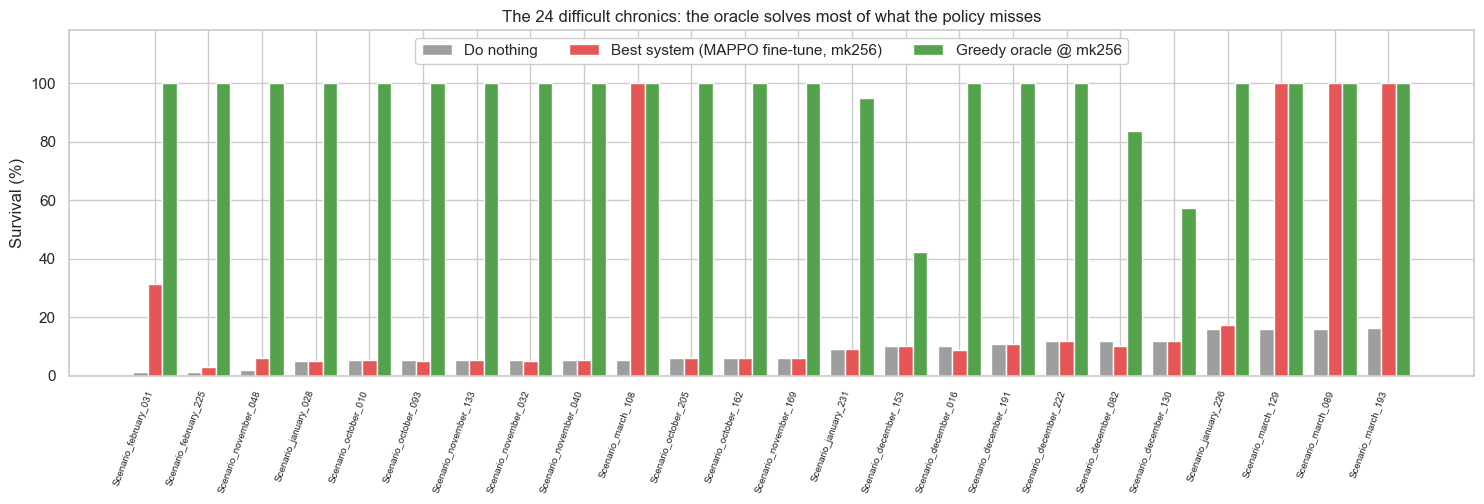

In [72]:
# The x-axis is fixed to the do-nothing ordering for every run drawn below, so
# two anatomy charts can be laid side by side and read column by column.
HARD_ORDER = (
    baseline.loc[baseline["is_hard"]]
    .sort_values("dn_survival")["chronic_name"].tolist()
)
RUN_PREVIEW = ["run"] + DIGEST_COLUMNS


def find_runs(query=None, *, scored_only=True, **filters):
    """Rows of `runs` matching a substring and/or exact factor filters.

    `query` is matched case-insensitively against the run stem, the key and the
    checkpoint stem. Filters are exact matches on any column of `runs`
    (`adaptation`, `mk`, `heuristic`, `rho`, `variant`, `family`, `pool`, ...);
    pass a list to match any of its members. Best `hard_pct` first.
    """
    frame = runs.dropna(subset=["hard_pct"]) if scored_only else runs
    if query is not None:
        haystack = (
            frame["run"].astype(str) + " " + frame["key"].astype(str)
            + " " + frame["checkpoint_stem"].astype(str)
        )
        frame = frame.loc[haystack.str.contains(str(query), case=False, regex=False)]
    for column, wanted in filters.items():
        if column not in frame.columns:
            raise KeyError(f"{column!r} is not a column of `runs`")
        wanted = list(wanted) if isinstance(wanted, (list, tuple, set)) else [wanted]
        frame = frame.loc[frame[column].isin(wanted)]
    return frame.sort_values("hard_pct", ascending=False)


def resolve_run(selector=None, *, rank=None, key=None, quiet=False, **filters):
    """Resolve a selector down to exactly one row of `runs`.

    Accepts a leaderboard `rank` (1 = top of §4), an exact `key`, a substring of
    the run name, and/or factor filters. When several runs match, the best one
    on `hard_pct` is taken and the alternatives are listed.
    """
    if rank is not None:
        if not 1 <= rank <= len(leaderboard):
            raise IndexError(f"rank must lie in 1..{len(leaderboard)}")
        key = leaderboard.iloc[rank - 1]["key"]
    if key is not None:
        matches = runs.loc[runs["key"] == key]
        if matches.empty:
            raise KeyError(f"no run with key {key!r}")
    else:
        matches = find_runs(selector, **filters)
        if matches.empty:
            raise LookupError(f"no scored run matches {selector!r} {filters}")
        if len(matches) > 1 and not quiet:
            display(Markdown(
                f"_{len(matches)} runs match — taking the best on `hard_pct`. "
                "Narrow the selector to pick another._"
            ))
            display(matches[RUN_PREVIEW].head(8))
    row = matches.iloc[0]
    if not row["has_episodes"]:
        raise ValueError(
            f"{row['run']} was downloaded as summary JSON only — it can be ranked "
            "on `overall_pct` but has no per-episode curve to draw (see §2)."
        )
    return row


def describe_run(row):
    gate = (
        "ungated" if row["heuristic"] == "none"
        else f"{row['heuristic']} {row['rho']:.2f}"
    )
    return f"{row['adaptation']} · mk{int(row['mk'])} · {gate} · {row['variant']}"


def plot_difficult_chronic_anatomy(
    selector=None, *, rank=None, key=None, order=None, show_greedy=True,
    label=None, title=None, save_as=None, ax=None, **filters,
):
    """Draw the §10 anatomy chart — do-nothing / one chosen run / greedy @ same mk.

    Pick the run with `rank=` (leaderboard position), `key=`, a substring of the
    run name, or factor filters such as `adaptation="MAPPO fine-tune", mk=256`.
    `order="model"` re-sorts the x-axis by the chosen run instead of the shared
    do-nothing ordering; `save_as="stem"` also writes the figure to EXPORT_DIR.
    Use `resolve_run(...)` with the same arguments to get the row itself.
    """
    row = resolve_run(selector, rank=rank, key=key, **filters)
    mk = int(row["mk"])

    model_curve = (
        episodes.loc[(episodes["key"] == row["key"]) & episodes["is_hard"],
                     ["chronic_name", "survival"]]
        .set_index("chronic_name")["survival"] * 100
    )
    dn_curve = (
        baseline.loc[baseline["is_hard"], ["chronic_name", "dn_survival"]]
        .set_index("chronic_name")["dn_survival"] * 100
    )
    greedy_curve = (
        greedy_episodes.loc[
            (greedy_episodes["mk"] == mk) & greedy_episodes["is_hard"],
            ["greedy_chronic_name", "greedy_survival"],
        ].set_index("greedy_chronic_name")["greedy_survival"] * 100
    )
    if show_greedy and greedy_curve.empty:
        display(Markdown(f"_No greedy oracle was run at mk{mk} — drawing without the ceiling._"))

    chronics = (
        model_curve.reindex(HARD_ORDER).sort_values().index.tolist()
        if order == "model" else HARD_ORDER
    )
    bars = [("Do nothing", dn_curve, "#9E9E9E"),
            (label or describe_run(row), model_curve, "#E45756")]
    if show_greedy and not greedy_curve.empty:
        bars.append((f"Greedy oracle @ mk{mk}", greedy_curve, "#54A24B"))

    owns_figure = ax is None
    if owns_figure:
        fig, ax = plt.subplots(figsize=(15.0, 5.2))
    positions = np.arange(len(chronics))
    width = 0.81 / len(bars)
    for offset, (bar_label, curve, colour) in zip(
        (np.arange(len(bars)) - (len(bars) - 1) / 2) * width, bars
    ):
        ax.bar(positions + offset, curve.reindex(chronics).to_numpy(),
               width=width, color=colour, label=bar_label)
    ax.set_xticks(positions, chronics, rotation=70, ha="right", fontsize=7)
    ax.set(ylabel="Survival (%)", ylim=(0, 118), title=title or (
        f"{describe_run(row)} — difficult {row['hard_pct']:.1f}%, "
        f"capture {row['capture_hard_pct']:.1f}%, "
        f"{int(row['hard_rescues'])}/{N_HARD} rescues"
    ))
    ax.legend(loc="upper center", ncol=len(bars), framealpha=0.95)
    if owns_figure:
        fig.tight_layout()
        if save_as:
            save_figure(fig, save_as)
        plt.show()


# The canonical §10 figure: the strongest run of any adaptation route.
best_key = best_per_init["key"].iloc[
    int(np.argmax(best_per_init["hard_pct"].to_numpy()))
]
best_row = runs.loc[runs["key"] == best_key].iloc[0]
plot_difficult_chronic_anatomy(
    key=best_key,
    label=f"Best system ({best_row['adaptation']}, mk{int(best_row['mk'])})",
    title=f"The {N_HARD} difficult chronics: the oracle solves most of what the policy misses",
    save_as="08_difficult_chronic_anatomy",
)

### Draw it for any run you like

`plot_difficult_chronic_anatomy(...)` renders the same three-bar chart for any
run that has per-episode artifacts. Pick one by leaderboard position, by name,
or by factor:

| call | picks |
|---|---|
| `plot_difficult_chronic_anatomy(rank=2)` | second row of the §4 leaderboard |
| `plot_difficult_chronic_anatomy(adaptation="MAPPO fine-tune", mk=256)` | best fine-tuned run at mk256 |
| `plot_difficult_chronic_anatomy(variant="NL_tmean_f0_a0h1", heuristic="none")` | that architecture, ungated |
| `plot_difficult_chronic_anatomy("orig_NL_tmean_f0_a0h1_mk128_lr100")` | run name substring |
| `plot_difficult_chronic_anatomy(key="<group>/<run>")` | one exact run |

Filters are exact matches on any column of `runs` — `adaptation`, `mk`,
`heuristic`, `rho`, `variant`, `family`, `pool`, `features`, `head`,
`checkpoint_step` — and a list matches any of its members. When several runs
match, the best on `hard_pct` is drawn and the alternatives are listed so the
selector can be narrowed; `find_runs(...)` returns that same match set without
plotting, for browsing. The x-axis keeps the shared do-nothing ordering so two
charts can be read column by column; pass `order="model"` to sort by the chosen
run instead, `show_greedy=False` to drop the oracle, and `save_as="stem"` to
write a PNG next to the other exports.

Runs without per-episode artifacts (§2) have no curve to draw and are refused
with an explicit error rather than a silent empty chart.

#### Candidates: `find_runs(variant="NL_tmean_f0_a0h1", mk=128)`

,run,adaptation,mk,heuristic,rho,variant,checkpoint_step,overall_pct,hard_pct,hard_rescues,easy_kept,capture_hard_pct,capture_overall_pct
125,orig_NL_tmean_f0_a0h1_mk64_lr095,bus14 zero-shot,64,local rho,0.95,NL_tmean_f0_a0h1,14598144,62.71,22.30,4.00,26.00,23.45,25.93
77,best_test_cas_hl_NL_shared_tmean_f0_a0h1_s0_mk64,bus14 zero-shot,64,none,NaN,NL_tmean_f0_a0h1,14598144,56.42,9.63,0.00,24.00,2.16,1.63


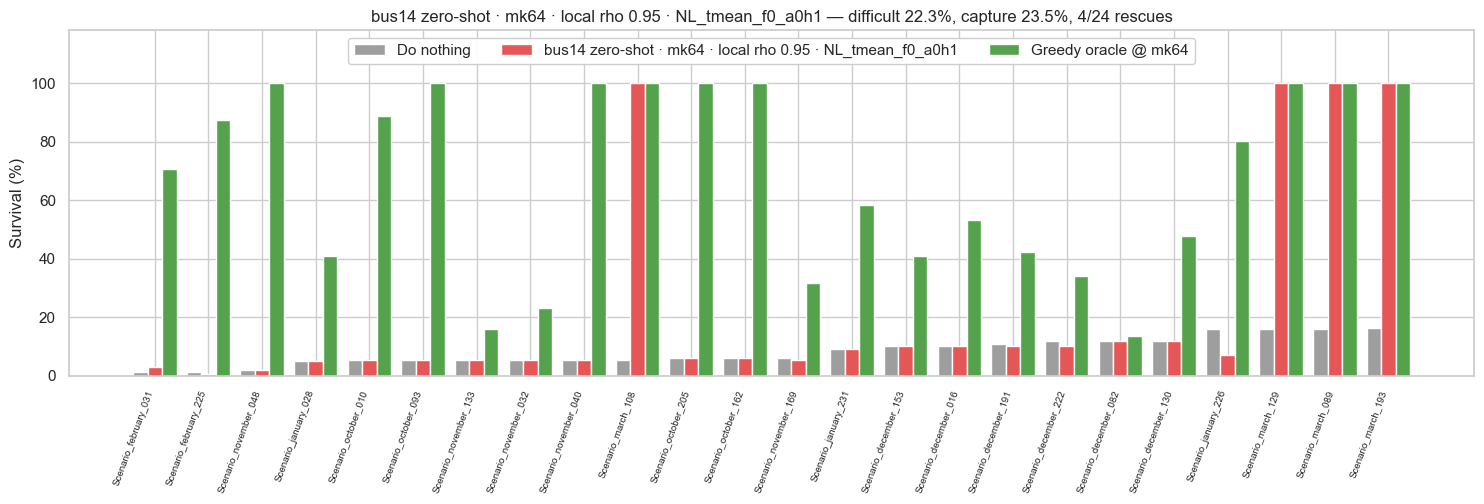

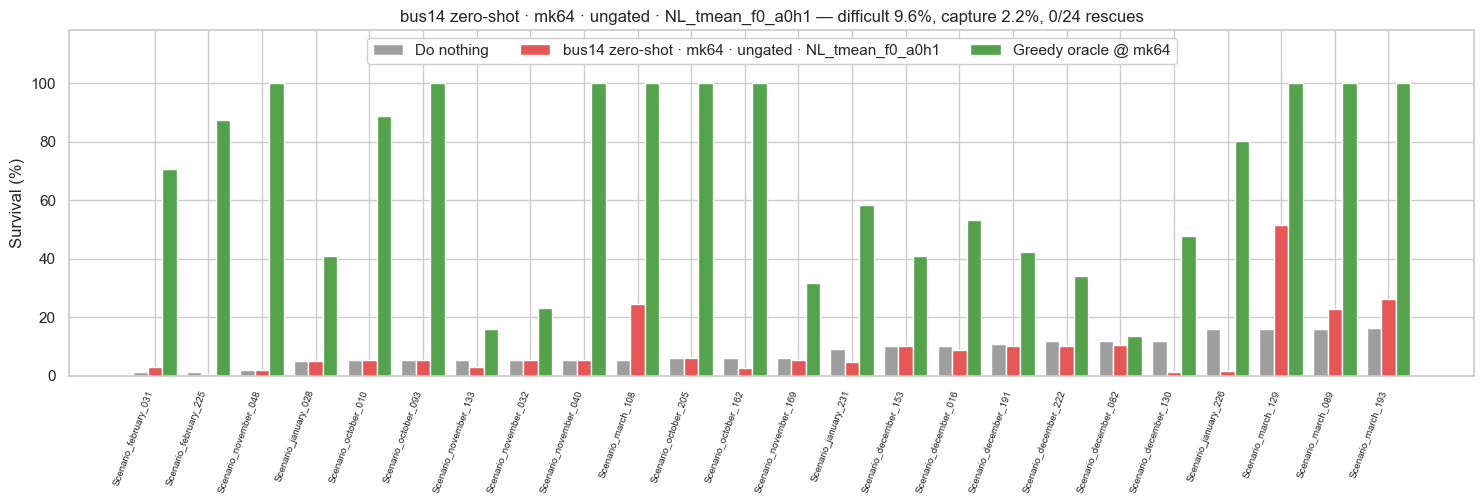

In [78]:
# Browse first — every scored run of one architecture at one action space.
display(Markdown("#### Candidates: `find_runs(variant=\"NL_tmean_f0_a0h1\", mk=128)`"))
display(find_runs(variant="NL_tmean_f0_a0h1", mk=64)[RUN_PREVIEW])

# Then plot whichever ones you want. Here: the same checkpoint at the same
# action space, gated and ungated — the largest lever in this digest, resolved
# chronic by chronic. The gated call matches four thresholds, so the best is
# drawn and the other three are listed.
plot_difficult_chronic_anatomy(variant="NL_tmean_f0_a0h1", mk=64, heuristic="local rho")
plot_difficult_chronic_anatomy(variant="NL_tmean_f0_a0h1", mk=64, heuristic="none")

In [74]:
RNG = np.random.default_rng(20260818)


def paired_bootstrap(key, cohort="hard", n_boot=20_000):
    frame = episodes.loc[episodes["key"] == key]
    if cohort == "hard":
        frame = frame.loc[frame["is_hard"]]
    delta = 100 * (frame["survival"] - frame["dn_survival"]).to_numpy()
    draws = delta[RNG.integers(0, len(delta), size=(n_boot, len(delta)))].mean(axis=1)
    return {
        "n_chronics": len(delta),
        "mean_delta_pp": delta.mean(),
        "ci95_low_pp": float(np.quantile(draws, 0.025)),
        "ci95_high_pp": float(np.quantile(draws, 0.975)),
        "wins": int((delta > 1e-9).sum()),
        "ties": int((np.abs(delta) <= 1e-9).sum()),
        "losses": int((delta < -1e-9).sum()),
    }


bootstrap_rows = []
for init, row in best_per_init.iterrows():
    for cohort in ("hard", "all"):
        bootstrap_rows.append({
            "adaptation": init, "run": row["run"], "cohort": cohort,
            **paired_bootstrap(row["key"], cohort),
        })
bootstrap = pd.DataFrame(bootstrap_rows)
display(Markdown(
    "#### Paired bootstrap over chronics, versus do-nothing\n\n"
    "Resamples the chronic pairs only. It does **not** cover training-seed noise or "
    "the optimism from having selected caps and thresholds on this same set, so a "
    "CI that excludes zero is a weak claim, not a strong one."
))
display(bootstrap)

#### Paired bootstrap over chronics, versus do-nothing

Resamples the chronic pairs only. It does **not** cover training-seed noise or the optimism from having selected caps and thresholds on this same set, so a CI that excludes zero is a weak claim, not a strong one.

,adaptation,run,cohort,n_chronics,mean_delta_pp,ci95_low_pp,ci95_high_pp,wins,ties,losses
0,MAPPO fine-tune,ft_mf0h0_lr095,hard,24,15.81,3.87,29.80,10,2,12
1,MAPPO fine-tune,ft_mf0h0_lr095,all,50,7.59,1.80,14.67,10,28,12
2,bus14 zero-shot,orig_NL_tmean_f0_a0h1_mk128_lr100,hard,24,15.33,3.64,29.50,11,9,4
3,bus14 zero-shot,orig_NL_tmean_f0_a0h1_mk128_lr100,all,50,7.36,1.70,14.53,11,35,4


## 11. Takeaways

The cell below regenerates every headline number from the data currently on disk,
so it stays correct as new runs are downloaded. The prose after it is the reading
of those numbers as of the current download.

In [75]:
best_overall_row = runs.sort_values("overall_pct", ascending=False).iloc[0]
best_hard_row = leaderboard.iloc[0]
ungated_best = runs.loc[runs["heuristic"] == "none", "hard_pct"].max()
gated_best = runs.loc[runs["heuristic"] != "none", "hard_pct"].max()

lines = [
    "## Auto-generated summary",
    "",
    f"- Comparable WCCI evaluations: **{len(runs)}** "
    f"({int(runs['hard_pct'].notna().sum())} with difficult-cohort metrics).",
    f"- Cohorts: **{N_HARD} difficult** / **{N_EASY} easy** of {N_EPISODES}.",
    f"- Do-nothing: overall **{DN_OVERALL:.2f}%**, difficult **{DN_HARD:.2f}%**.",
    f"- Greedy oracle: difficult **{GREEDY_HARD[64]:.2f}%** at mk64 → "
    f"**{GREEDY_HARD[256]:.2f}%** at mk256.",
    "",
    f"- Best difficult-cohort system: **{best_hard_row['run']}** "
    f"({best_hard_row['adaptation']}, mk{int(best_hard_row['mk'])}, "
    f"{best_hard_row['heuristic']}) — difficult **{best_hard_row['hard_pct']:.2f}%**, "
    f"overall {best_hard_row['overall_pct']:.2f}%, "
    f"{int(best_hard_row['hard_rescues'])}/{N_HARD} rescues, "
    f"{int(best_hard_row['easy_kept'])}/{N_EASY} easy kept.",
    f"- It captures **{best_hard_row['capture_hard_pct']:.1f}%** of the greedy headroom "
    f"on difficult chronics ({best_hard_row['capture_overall_pct']:.1f}% overall).",
    f"- Best on the overall mean: **{best_overall_row['run']}** at "
    f"{best_overall_row['overall_pct']:.2f}%"
    + ("" if best_overall_row["has_episodes"] else " *(no per-episode artifacts — difficult-cohort standing unknown)*")
    + ".",
    "",
    f"- Gating lever: best ungated difficult **{ungated_best:.2f}%** → "
    f"best gated **{gated_best:.2f}%** (**{gated_best - ungated_best:+.2f} pp**).",
    "- Action-space lever, zero-shot ungated difficult survival — best run: "
    + " → ".join(
        f"**{cap_summary.loc[cap_summary['mk'] == mk, 'hard_best'].max():.1f}%** (mk{mk})"
        for mk in MK_ORDER
    ) + ".",
    "- Same sweep, mean over the 16 architecture variants: "
    + " → ".join(
        f"**{cap_summary.loc[cap_summary['mk'] == mk, 'hard_mean'].mean():.1f}%** (mk{mk})"
        for mk in MK_ORDER
    ) + f" — against a greedy ceiling rising from {GREEDY_HARD[64]:.0f}% to {GREEDY_HARD[1024]:.0f}%.",
    f"- Threshold sensitivity: the best local-rho curve varies by only "
    f"**{leader_spread['spread_pp']:.2f} pp** across its thresholds; the most sensitive "
    f"curve varies by **{curve_spread['spread_pp'].max():.2f} pp**, and it is a "
    f"mid-table configuration.",
    f"- Collapse rate: **{int((zero_ungated['hard_pct'] < 0.5).sum())}/{len(zero_ungated)}** "
    f"zero-shot ungated runs die within a few steps on the difficult chronics.",
    f"- Source-grid correlation: bus14 survival vs WCCI difficult survival "
    f"r = **{correlation:+.2f}**.",
    "",
    f"- Adaptation routes downloaded: "
    + " · ".join(
        f"**{route}** ({int(count)} eval)"
        for route, count in runs["adaptation"].value_counts().sort_index().items()
    ) + ".",
]
if not bc_runs.empty:
    gate_summary = gate_effect["gate_gain_pp"].dropna() if "gate_gain_pp" in gate_effect else pd.Series(dtype=float)
    lines += [
        f"- Controlled route comparison (`{best_cell_key['variant']}` @ "
        f"mk{int(best_cell_key['mk'])}), value of the local-rho gate: "
        + " · ".join(f"**{route}** {gain:+.2f} pp" for route, gain in gate_summary.items())
        + ".",
        f"- BC ungated `{bc_runs.loc[bc_runs['heuristic'] == 'none', 'overall_pct'].max():.2f}%` "
        f"(below the do-nothing floor of `{DN_OVERALL:.2f}%`) vs BC gated "
        f"`{bc_runs['overall_pct'].max():.2f}%` — the same checkpoint, and the largest "
        "gate effect of any route.",
    ]
lines += [
    "",
    f"- Rescue concentration: for the best system, "
    f"**{decomposition.iloc[0]['pp_from_rescues'] / decomposition.iloc[0]['total_overall_gain_pp']:.0%}** "
    f"of the headline gain comes from "
    f"{int(decomposition.iloc[0]['rescued_chronics'])} fully rescued chronics.",
    f"- Paired record on the difficult cohort for the best system: "
    f"**{int(bootstrap.iloc[0]['wins'])} wins / {int(bootstrap.iloc[0]['ties'])} ties / "
    f"{int(bootstrap.iloc[0]['losses'])} losses** vs do-nothing, "
    f"mean {bootstrap.iloc[0]['mean_delta_pp']:+.1f} pp "
    f"(95% CI {bootstrap.iloc[0]['ci95_low_pp']:+.1f} to {bootstrap.iloc[0]['ci95_high_pp']:+.1f} pp).",
]
display(Markdown("\n".join(lines)))

## Auto-generated summary

- Comparable WCCI evaluations: **139** (126 with difficult-cohort metrics).
- Cohorts: **24 difficult** / **26 easy** of 50.
- Do-nothing: overall **56.00%**, difficult **8.34%**.
- Greedy oracle: difficult **67.88%** at mk64 → **94.92%** at mk256.

- Best difficult-cohort system: **ft_mf0h0_lr095** (MAPPO fine-tune, mk256, local rho) — difficult **24.15%**, overall 63.59%, 4/24 rescues, 26/26 easy kept.
- It captures **18.3%** of the greedy headroom on difficult chronics (18.3% overall).
- Best on the overall mean: **ft64c_NLS_mean_f0_a0h0_s0_lr095** at 63.65% *(no per-episode artifacts — difficult-cohort standing unknown)*.

- Gating lever: best ungated difficult **17.60%** → best gated **24.15%** (**+6.55 pp**).
- Action-space lever, zero-shot ungated difficult survival — best run: **17.3%** (mk64) → **17.6%** (mk128) → **17.4%** (mk256) → **14.9%** (mk512) → **1.2%** (mk1024).
- Same sweep, mean over the 16 architecture variants: **5.8%** (mk64) → **5.0%** (mk128) → **4.0%** (mk256) → **2.1%** (mk512) → **0.4%** (mk1024) — against a greedy ceiling rising from 68% to 90%.
- Threshold sensitivity: the best local-rho curve varies by only **1.14 pp** across its thresholds; the most sensitive curve varies by **4.08 pp**, and it is a mid-table configuration.
- Collapse rate: **33/80** zero-shot ungated runs die within a few steps on the difficult chronics.
- Source-grid correlation: bus14 survival vs WCCI difficult survival r = **-0.01**.

- Adaptation routes downloaded: **bus14 zero-shot** (118 eval) · **MAPPO fine-tune** (18 eval) · **BC on greedy labels** (2 eval) · **MAPPO scratch** (1 eval).
- Controlled route comparison (`NLS_mean_f1_a0h0` @ mk64), value of the local-rho gate: **bus14 zero-shot** -4.25 pp · **MAPPO fine-tune** -0.12 pp · **BC on greedy labels** +8.61 pp.
- BC ungated `54.02%` (below the do-nothing floor of `56.00%`) vs BC gated `62.62%` — the same checkpoint, and the largest gate effect of any route.

- Rescue concentration: for the best system, **91%** of the headline gain comes from 4 fully rescued chronics.
- Paired record on the difficult cohort for the best system: **10 wins / 2 ties / 12 losses** vs do-nothing, mean +15.8 pp (95% CI +3.9 to +29.8 pp).

### Reading of the current download

1. **The overall mean is not the result.** 26 of 50 chronics are free wins that
   do-nothing already collects, and every top system keeps all 26. The whole
   spread of interest is compressed into the upper half of `overall_%`: the top
   twelve systems sit inside 2 pp of each other overall while spanning 6 pp on the
   difficult cohort. Report `hard_%`, and report `capture_hard_%` next to it.

2. **Intervention *timing* is the dominant lever — bigger than architecture, cap or
   fine-tuning.** Bolting a local-rho gate onto an unchanged checkpoint is worth a
   median `+3.9 pp` on the difficult cohort across the 38 matched pairs, and moves
   the best-of-all system from `17.6 %` to `24.2 %`. Which threshold you pick between
   0.85 and 1.00 is close to irrelevant *for the configurations that work*: the best
   fully-swept curve — `NL_tmean_f0_a0h1` at mk128, all four thresholds — moves by
   `0.004 pp` end to end, and rows 2–6 of the leaderboard are that one checkpoint at
   four thresholds. The top curve overall (`NLS_mean_f0_a0h0` fine-tuned at mk256) was
   swept at only two thresholds and moves `1.1 pp`. Sensitivity is concentrated in
   mid-table models (up to `4.1 pp`), so a large threshold effect reads as a symptom of
   a fragile configuration rather than a tuning opportunity. All of this is a statement
   about the actor: it has learned **which** action
   to propose far better than **when** to propose it, and two lines of heuristic
   supply the missing calibration. A learned intervention gate is the obvious next
   experiment.

3. **A bigger action space helps the oracle and hurts the policy.** The greedy
   ceiling rises with the cap while transferred policies flatten and then collapse.
   Capability is present in the candidate set; the transferred scorer cannot exploit
   it. Note the consequence for `capture`: the best mk128 system captures more of its
   headroom (`25.6 %`) than the higher-scoring mk256 system does (`18.3 %`), because
   mk256 offers far more that is left on the table. **Ranking by raw survival hides
   this; ranking by capture does not.**

4. **Nothing is close to the ceiling.** The best system reaches `24.2 %` on the
   difficult cohort where the oracle *with the same 256 candidate actions* reaches
   `94.9 %`, and rescues 4 of 24 difficult chronics against the oracle's 20. Roughly
   four-fifths of the reachable headroom is still unclaimed. That gap — not the
   margin over do-nothing — is the honest measure of how open this problem is.

5. **The headline gain is four episodes.** For the best system, ~91 % of the
   `+7.6 pp` overall improvement comes from 4 fully rescued chronics; everything
   else contributes under a point. Worse, on the difficult cohort that system
   records **10 wins, 2 ties and 12 losses** against do-nothing — it wins big on a
   few chronics and loses on half of them. The paired bootstrap CI on the difficult
   cohort spans `+3.9` to `+29.8 pp`. Ranking two systems a fraction of a point apart
   is reading noise.

6. **Architecture failure is an interaction, and when it hits it is total.** Plain
   `mean` candidate pooling combined with `f0` (no candidate features) does not merely
   underperform — **all 20 of its runs collapse**, at every cap, dying within a handful
   of steps. That is a cap-independent representation failure, not a tuning problem.
   Its mirror image is `typed-mean` + `f0`, which collapses in only 1 of 20 runs and
   only at mk1024. Neither pooling is safe on its own: collapse also tracks the cap,
   rising from 5 of 16 variants at mk64 to 10 of 16 at mk1024. So the candidate
   representation is what does or does not survive the grid change — the same
   ranking-generalisation failure as point 3, seen at its extreme.

7. **bus14 skill buys nothing on WCCI.** Across the 16 variants, source survival and
   transferred difficult-cohort survival correlate at **r = −0.01**. Two variants at
   `100 %` on bus14 land at `0.05 %` and `9.7 %` respectively on WCCI. Source-grid
   model selection is selecting for something the target grid does not reward — any
   checkpoint-selection criterion for transfer has to be built on target-side or
   held-out evidence.

8. **MAPPO fine-tuning and behaviour cloning are not the same operation, and the
   difference is about *when* the policy acts.** Holding architecture, action space and
   seed fixed (`NLS_mean_f1_a0h0` @ mk64), the local-rho gate is worth `−4.3 pp` to the
   zero-shot actor, `−0.1 pp` to the MAPPO fine-tune, and **`+8.6 pp` to the BC model**.
   Ungated, BC is the *worst* of the three and sits `2.0 pp` **below do-nothing**; gated,
   it is the best. That is the direct signature of its supervision: the expert labels
   only exist at states with max rho ≥ 0.90, so BC has no defined behaviour in the safe
   states that make up most of an episode. **For a BC model the rho gate is not a
   deployment tweak, it is part of the model's contract** — reporting BC ungated is
   reporting it outside its training distribution. The practical consequence is that
   MAPPO fine-tuning and BC should not be scored on the same protocol: BC needs its
   gate declared as part of the system.

9. **BC is distilling the very oracle this notebook measures against.** Its teacher is
   the one-step simulator greedy restricted to the same reduced action space — the
   denominator of `capture_hard_%`. So for BC that column is teacher-reproduction
   fidelity, and the gated BC model currently recovers about a quarter of its teacher's
   margin over do-nothing. That framing also bounds the method: BC cannot exceed greedy
   on the states it was trained on, so its upside is the oracle's `94.9 %` at mk256, not
   more. Its appeal is that it reaches for that ceiling with supervised gradients rather
   than PPO exploration.

10. **No route is separated from another on the overall mean alone.** The four routes
    land within a few points of each other at mk64, on very different budgets
    (0.17 M–5 M PPO steps, or 12 BC epochs over ~1 496 states) and single seeds. The
    route comparison cannot be settled on `overall_%`, and the difficult-cohort
    comparison cannot be made at all until the MAPPO-fine-tune and BC artifacts are
    re-synced.

### What would make these conclusions stand up

* Re-sync the missing `ft64c_*` per-episode artifacts — the run that currently leads
  the overall mean cannot be placed on the metric that matters.
* Select the cap and the rho threshold on **validation** chronics, then evaluate once
  on fresh held-out chronics.
* Replicate the leading configurations over ≥3 training seeds before comparing arms
  that sit within a couple of points of each other.
* Report `capture_hard_%` against greedy-at-the-same-mk as the primary number in
  write-ups; it is the only one of these metrics that is not inflated by free episodes.
* Test the "timing, not selection" hypothesis directly: a learned intervention gate,
  or an oracle-timing ablation that gives the current actor the greedy gate's decision
  points, would separate the ranking failure from the timing failure.
* Report wins/ties/losses on the difficult cohort alongside the mean. A system that
  loses on half the difficult chronics but rescues four is a different object from
  one that improves broadly, and the mean cannot tell them apart.
* Extend the BC arm before drawing conclusions from it: it is currently **one
  architecture, one action space, one seed, two evaluations**. The obvious next runs are
  the `tmean_f0_a0h0` control from the same labels, the mk128/mk256 datasets that were
  collected alongside mk64, and the `bcg` recipe applied *on top of* a MAPPO fine-tune
  rather than direct from bus14 — that last one separates "BC instead of PPO" from
  "BC after PPO".
* Sweep the BC gate threshold. Labels were collected at rho ≥ 0.90 but the only gated
  BC evaluation uses 0.95; matching the gate to the collection threshold is the natural
  first ablation, and it is currently untested.
* If BC's advantage is really about action timing, the `aux_intervention` head it was
  trained with is a learned gate in embryo. Evaluating it *as* the gate, instead of the
  hand-written rho rule, is the cleanest test of the "timing, not selection" hypothesis.

## 12. Exports

In [76]:
exports = {
    "run_metrics.csv": runs.drop(columns=["episode_csv"]),
    "leaderboard_by_difficult.csv": leaderboard,
    "episode_metrics.csv": episodes,
    "greedy_ceiling.csv": greedy_ceiling,
    "digest_matrix_hard.csv": best_cell(runs, "hard_pct").reset_index(),
    "digest_matrix_capture.csv": best_cell(runs, "capture_hard_pct").reset_index(),
    "action_space_summary.csv": cap_summary,
    "heuristic_matched_gains.csv": matched,
    "adaptation_summary.csv": init_summary,
    "architecture_marginals.csv": architecture_marginals,
    "source_vs_transfer.csv": transfer_link,
    "best_system_decomposition.csv": decomposition,
    "paired_bootstrap.csv": bootstrap,
    "coverage_gap.csv": coverage_gap,
}
for name, frame in exports.items():
    frame.to_csv(EXPORT_DIR / name, index=False)
print(f"{len(exports)} tables + 8 figures written to:\n{EXPORT_DIR}")

14 tables + 8 figures written to:
/Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task/outputs/analysis/shared_wcci_transfer_digest
